In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy import stats
import json
from scipy.spatial import procrustes
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import euclidean
from sklearn.decomposition import PCA
import warnings

df = pd.read_csv("Data/arabesque_analysis_ready_updated.csv")

print(f"Original dataset size: {len(df)} frames")

# ==========================================
# 1. FEATURE SELECTION
# ==========================================
FEATURES = [
    'video', 'filename', 'year', 'decade', 'real_gender', 'json_path', # Metadata & Identifiers
    # --- Group 1: Height & Distance Metrics ---
    'foot_height_diff',           # Height difference between feet
    'dist_highest_wrist_ank',     # Distance between highest wrist and raised ankle (Grab leg proxy)
    'arm_symmetry',               # Vertical difference between left and right wrists
    
    # --- Group 2: Leg & Core Angles ---
    'split_angle',                # Absolute leg span
    'raised_knee_angle',          # Raised knee extension
    'support_knee_angle',         # Support knee extension
    'support_leg_plumb',          # Support leg vertical alignment
    
    # --- Group 3: Torso, Spine & Pelvis ---
    'torso_tilt',                 # Torso forward tilt
    'arabesque_angle',            # Angle between raised leg and torso
    'pelvic_anterior_tilt',       # Pelvic anterior tilt
    'lumbar_arch',                # Lumbar arch (Spine-Thorax)
    'pelvic_tilt_angle',          # Pelvic tilt 
    'thoracic_neck_angle',        # Thoracic-Neck line
    
    # --- Group 4: Arm & Upper Body Angles ---
    'l_elbow_angle',              # Left elbow extension
    'r_elbow_angle',              # Right elbow extension
    'highest_arm_vertical_angle', # Arm verticality
    
    # --- Group 5: Torsion (Experimental, keep for testing) ---
    'shoulder_hip_torsion'        # 2D horizontal twist between shoulders and hips
]

df_selected = df[[col for col in FEATURES if col in df.columns]].copy()

# ==========================================
# 2. BIOMECHANICAL FILTERING (Hard Constraints)
# ==========================================
# Ballet poses have physical limits. If the 3D model predicts angles outside these 
# boundaries, it is a severe prediction failure and should be dropped.

# Constraint A: Knee Extension
# In an arabesque, both knees should be relatively straight. 
# A knee angle < 90 degrees is anatomically incorrect for this specific pose.
MIN_KNEE_ANGLE = 90.0 

# Constraint B: Split Angle (Leg Span)
MIN_SPLIT = 30.0
MAX_SPLIT = 180.0

# Apply filters
valid_pose_mask = (
    (df_selected['raised_knee_angle'] >= MIN_KNEE_ANGLE) &
    (df_selected['support_knee_angle'] >= MIN_KNEE_ANGLE) &
    (df_selected['split_angle'] >= MIN_SPLIT) &
    (df_selected['split_angle'] <= MAX_SPLIT)
)

df_clean_bio = df_selected[valid_pose_mask].copy()

dropped_bio = len(df_selected) - len(df_clean_bio)
print(f"Dropped {dropped_bio} frames due to biomechanical impossibility (Model Failures).")

Original dataset size: 792 frames
Dropped 7 frames due to biomechanical impossibility (Model Failures).


In [2]:
# ==========================================
# 3. STATISTICAL SMOOTHING (IQR Filter per Group)
# ==========================================
def remove_outliers_iqr(group_df, column_name, multiplier=1.5):
    """
    Removes outliers from a dataframe based on the Interquartile Range (IQR) method.
    """
    Q1 = group_df[column_name].quantile(0.25)
    Q3 = group_df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - (multiplier * IQR)
    upper_bound = Q3 + (multiplier * IQR)
    
    # Return a boolean mask of valid rows
    return (group_df[column_name] >= lower_bound) & (group_df[column_name] <= upper_bound)

# We want to remove outliers based on our most critical metrics
TARGET_METRICS = ['split_angle', 'torso_tilt', 'arabesque_angle']

# Create a master mask initialized to True for all rows
final_mask = pd.Series(True, index=df_clean_bio.index)

# Group by Decade and Gender to apply context-aware IQR filtering
groupby_cols = ['decade', 'real_gender']

for name, group in df_clean_bio.groupby(groupby_cols):
    group_mask = pd.Series(True, index=group.index)
    
    for metric in TARGET_METRICS:
        if metric in group.columns:
            # Get valid rows for this specific metric
            metric_mask = remove_outliers_iqr(group, metric)
            # Combine with the group's overall mask
            group_mask = group_mask & metric_mask
            
    # Update the master mask for the indices belonging to this group
    final_mask.loc[group.index] = group_mask

df_final_clean = df_clean_bio[final_mask].copy()

dropped_stat = len(df_clean_bio) - len(df_final_clean)
print(f"Dropped {dropped_stat} frames during Decade/Gender-specific IQR smoothing.")
print(f"Final dataset size ready for diachronic analysis: {len(df_final_clean)} frames")

df_final_clean.to_csv("Data/arabesque_cleaned_for_analysis.csv", index=False)

Dropped 47 frames during Decade/Gender-specific IQR smoothing.
Final dataset size ready for diachronic analysis: 738 frames


#### Feature Correlation Analysis

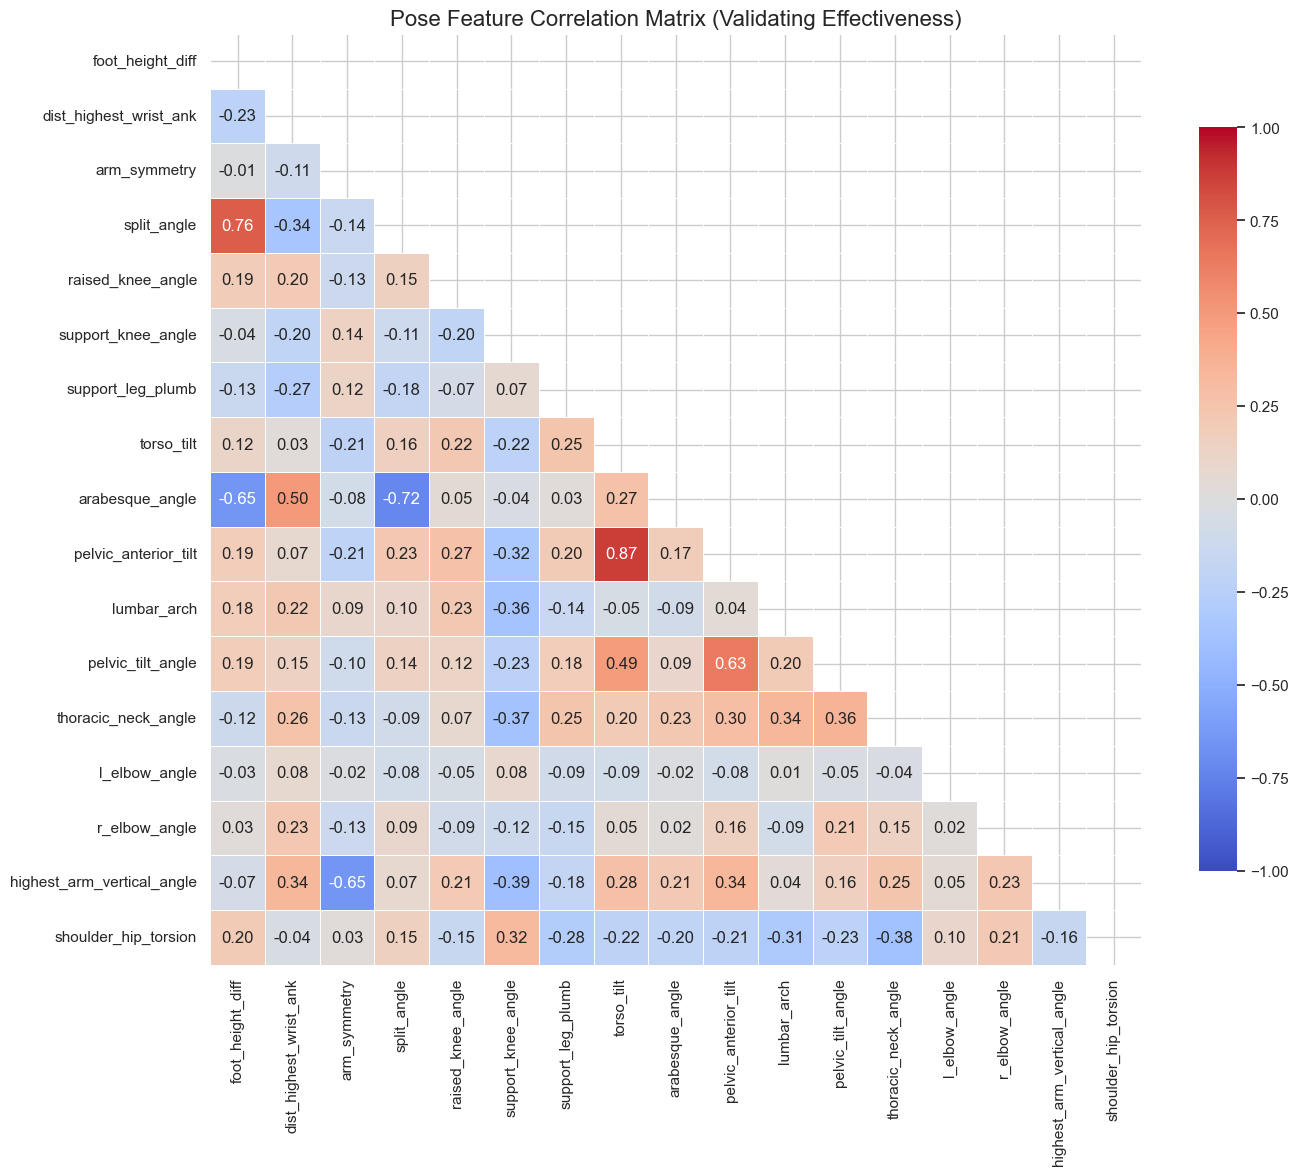

In [3]:
sns.set_theme(style="whitegrid", palette="muted")

df = pd.read_csv("Data/arabesque_cleaned_for_analysis.csv")

exclude_cols = ['year', 'decade', 'video', 'filename', 'real_gender', 'json_path']
feature_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col not in exclude_cols]

corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap='coolwarm', 
    vmax=1.0, vmin=-1.0, 
    center=0, 
    annot=True,   
    fmt='.2f',      
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .75}
)
plt.title('Pose Feature Correlation Matrix (Validating Effectiveness)', fontsize=16)
plt.tight_layout()
plt.show()

In [4]:
columns_to_drop = [
    'pelvic_anterior_tilt',  # & torso_tilt (r = 0.87)
    'foot_height_diff',      # & split_angle (r = 0.76)
]

cols_existing = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=cols_existing)

#### Temporal Trend Analysis (Mean Value)

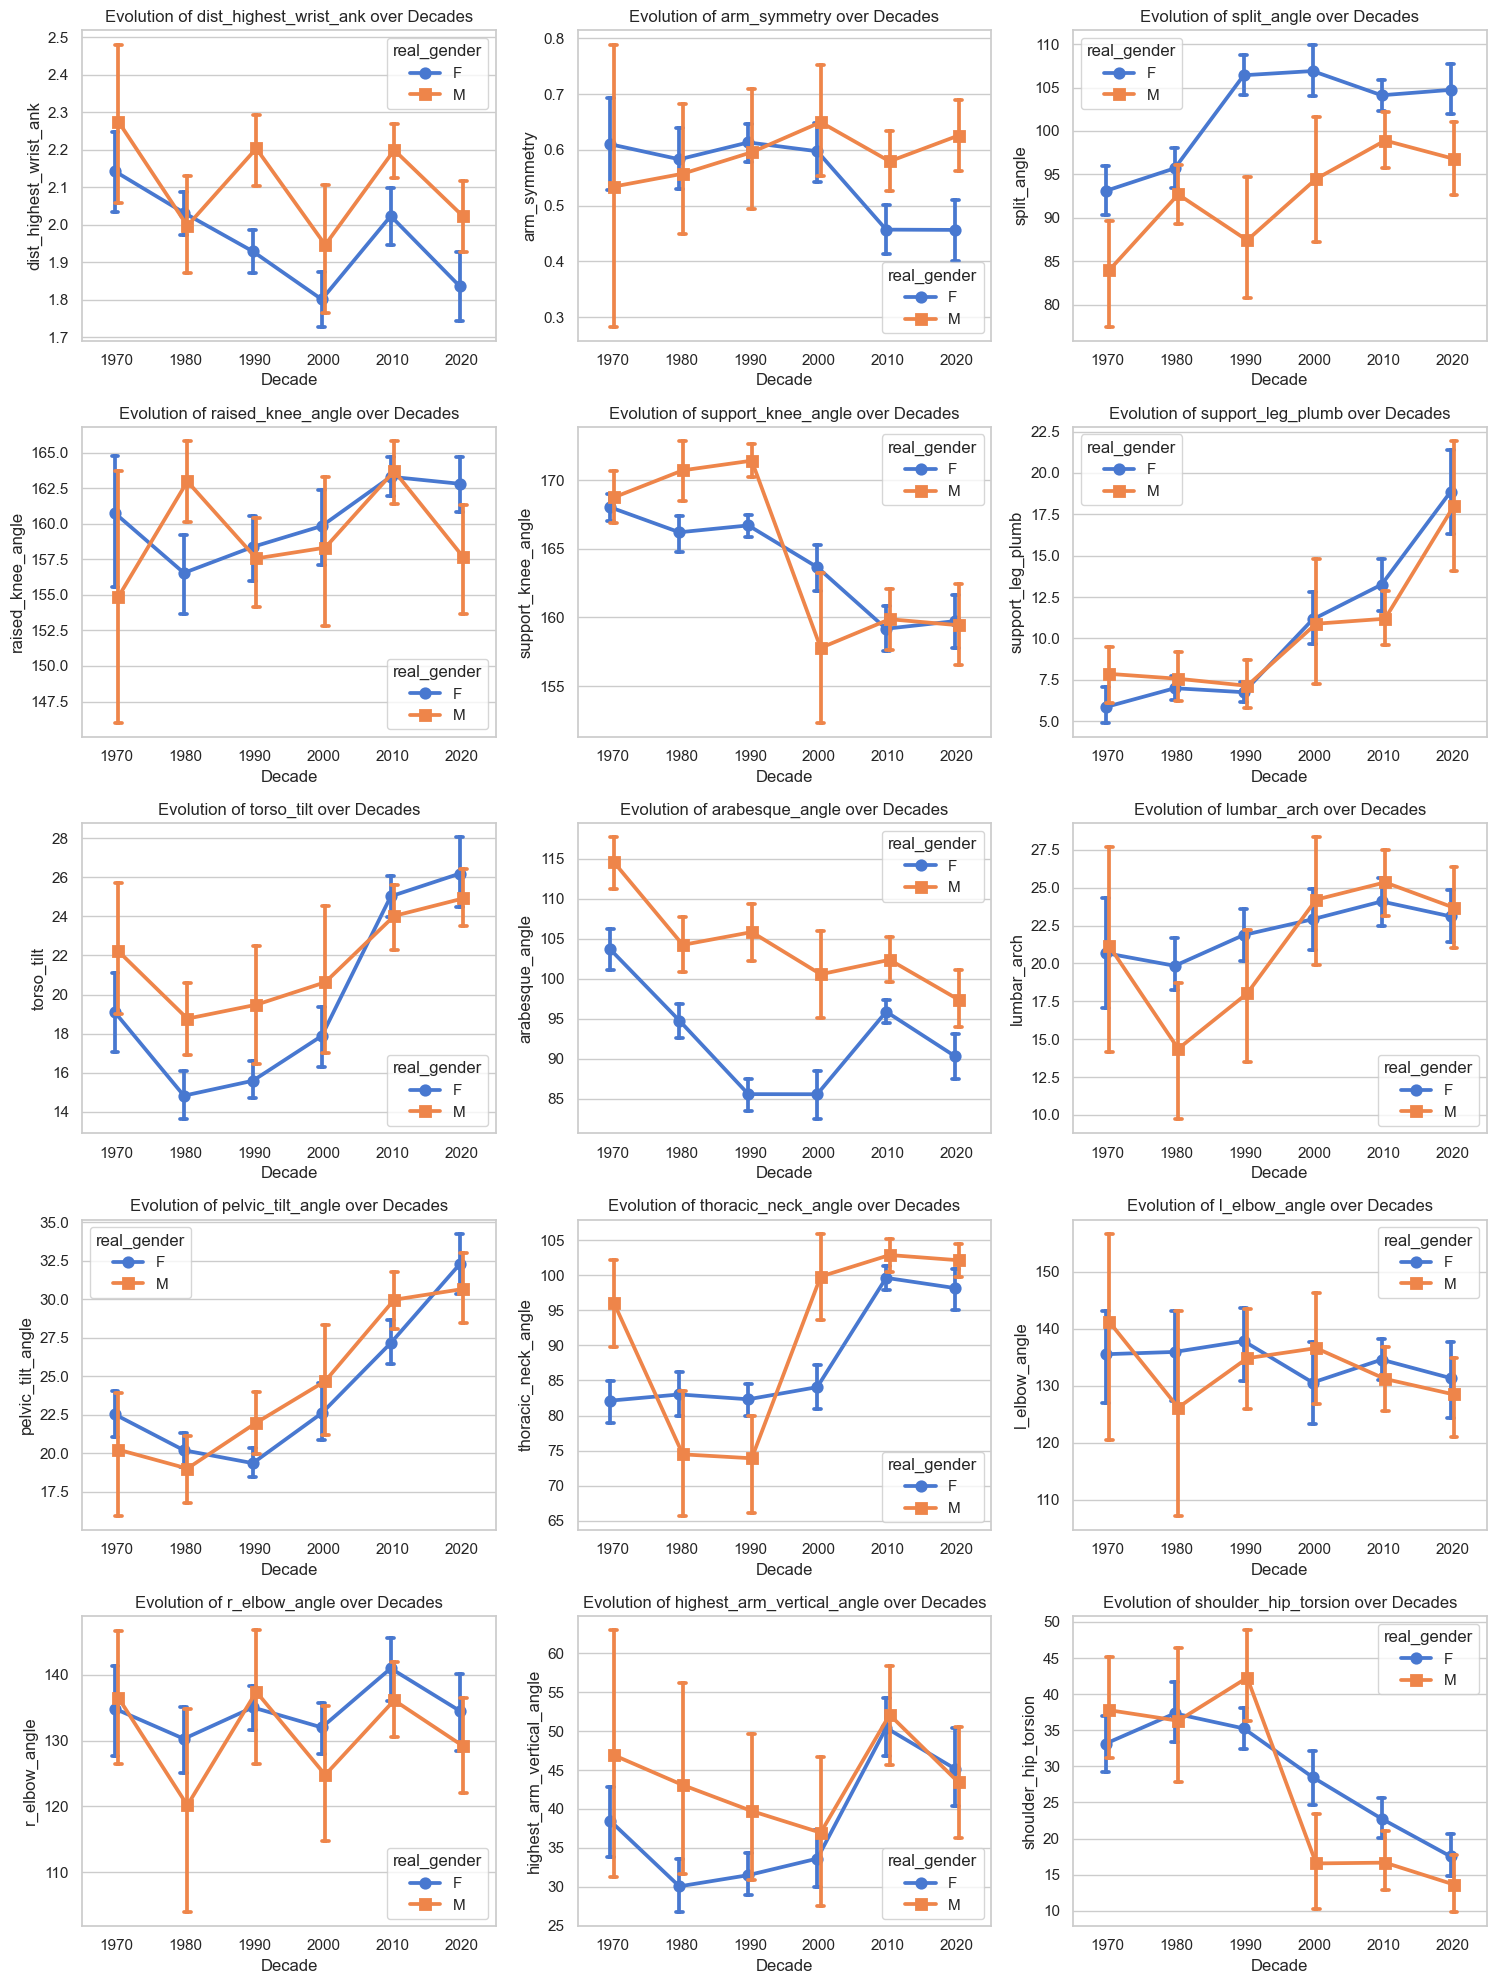

In [6]:
exclude_cols = ['year', 'decade', 'video', 'filename', 'real_gender', 'json_path']
feature_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col not in exclude_cols]

df = df[df['real_gender'].isin(['M', 'F'])].copy()
df['decade'] = pd.Categorical(df['decade'], ordered=True)
df = df.sort_values('decade')

num_features = len(feature_cols)
cols = 3  
rows = math.ceil(num_features / cols)

width_per_plot = 5  
height_per_plot = 4  

fig_width = cols * width_per_plot
fig_height = rows * height_per_plot

fig, axes = plt.subplots(rows, cols, figsize=(fig_width, fig_height))
axes = axes.flatten()

for i, metric in enumerate(feature_cols):
    sns.pointplot(
        data=df, 
        x='decade', 
        y=metric, 
        hue='real_gender', 
        dodge=True,
        markers=['o', 's'], 
        capsize=.1,
        ax=axes[i]
    )
    axes[i].set_title(f'Evolution of {metric} over Decades')
    axes[i].set_xlabel('Decade')
    axes[i].set_ylabel(metric)

for j in range(num_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [7]:
df['decade'] = df['decade'].astype(str)
df['real_gender'] = df['real_gender'].astype(str)

target_metrics = [
    'split_angle',         
    'support_leg_plumb',   
    'torso_tilt',          
    'arabesque_angle',     
    'lumbar_arch',         
    'pelvic_tilt_angle',
    'thoracic_neck_angle',
    'shoulder_hip_torsion'    
]

df_female = df[df['real_gender'] == 'F']
df_male = df[df['real_gender'] == 'M']

for metric in target_metrics:
    print(f"\n" + "="*60)
    print(f"📊 Feature: {metric}")
    print("="*60)
    
    df_clean = df.dropna(subset=[metric, 'decade', 'real_gender']).copy()
    
    if df_clean.empty:
        print(f"⚠️ {metric} is Null, skip。")
        continue

    # ==========================================
    # Two-Way ANOVA
    # ==========================================
    formula = f'{metric} ~ C(decade) + C(real_gender) + C(decade):C(real_gender)'
    
    try:
        model = ols(formula, data=df_clean).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        
        def get_stars(p):
            if p < 0.001: return '***'
            elif p < 0.01: return '**'
            elif p < 0.05: return '*'
            else: return 'ns'
            
        anova_table['Significance'] = anova_table['PR(>F)'].apply(get_stars)
        
        print("\n[1] Two-Way ANOVA:")
        print(anova_table[['F', 'PR(>F)', 'Significance']])
        
        # ==========================================
        # Tukey Post-Hoc Test
        # ==========================================
        p_decade = anova_table.loc['C(decade)', 'PR(>F)']
        
        if p_decade < 0.05:
            print(f"\n[2] {metric} has significant difference between decades (p={p_decade:.4f}).")
            print(">>> Run Tukey Post-Hoc Test:")
            
            tukey = pairwise_tukeyhsd(endog=df_clean[metric], groups=df_clean['decade'], alpha=0.05)
            
            tukey_df = pd.DataFrame(data=tukey._results_table.data[1:], columns=tukey._results_table.data[0])
            
            significant_pairs = tukey_df[tukey_df['reject'] == True]
            
            if not significant_pairs.empty:
                print("\nSignificant Decade Pair (reject=True):")
                print(significant_pairs[['group1', 'group2', 'meandiff', 'p-adj']])
            else:
                print("⚠️ No significant jump between decades.")

            print("\n>>> Tukey Post-Hoc Test (Female):")
            tukey_female = pairwise_tukeyhsd(endog=df_female[metric], groups=df_female['decade'], alpha=0.05)
            tukey_df_f = pd.DataFrame(data=tukey_female._results_table.data[1:], columns=tukey_female._results_table.data[0])
            significant_pairs_f = tukey_df_f[tukey_df_f['reject'] == True]
            
            if not significant_pairs_f.empty:
                print("\nSignificant Decade Pair (reject=True):")
                print(significant_pairs_f[['group1', 'group2', 'meandiff', 'p-adj']])
            else:
                print("⚠️ No significant jump between decades.")

            print("\n>>> Tukey Post-Hoc Test (Male):")
            tukey_male = pairwise_tukeyhsd(endog=df_male[metric], groups=df_male['decade'], alpha=0.05)
            tukey_df_m = pd.DataFrame(data=tukey_male._results_table.data[1:], columns=tukey_male._results_table.data[0])
            significant_pairs_m = tukey_df_m[tukey_df_m['reject'] == True]
            
            if not significant_pairs_m.empty:
                print("\nSignificant Decade Pair (reject=True):")
                print(significant_pairs_m[['group1', 'group2', 'meandiff', 'p-adj']])
            else:
                print("⚠️ No significant jump between decades.")
                
        else:
            print(f"\n[2] {metric} has no significant difference between decades (p={p_decade:.4f}).")

    except Exception as e:
        print(f"❌ Something wrong when analyzing {metric}: {e}")



📊 Feature: split_angle

[1] Two-Way ANOVA:
                                  F        PR(>F) Significance
C(decade)                 13.755692  7.517280e-13          ***
C(real_gender)            56.648678  1.553334e-13          ***
C(decade):C(real_gender)   4.048897  1.245671e-03           **
Residual                        NaN           NaN           ns

[2] split_angle has significant difference between decades (p=0.0000).
>>> Run Tukey Post-Hoc Test:

Significant Decade Pair (reject=True):
  group1 group2  meandiff   p-adj
1   1970   1990   11.8737  0.0000
2   1970   2000   12.9969  0.0000
3   1970   2010   10.8370  0.0000
4   1970   2020   10.2132  0.0003
5   1980   1990    8.4899  0.0000
6   1980   2000    9.6131  0.0000
7   1980   2010    7.4532  0.0001
8   1980   2020    6.8295  0.0023

>>> Tukey Post-Hoc Test (Female):

Significant Decade Pair (reject=True):
  group1 group2  meandiff   p-adj
1   1970   1990   13.3097  0.0000
2   1970   2000   13.7943  0.0000
3   1970   2010  

In [8]:
target_metrics = [
    'split_angle',         
    'support_leg_plumb',   
    'torso_tilt',          
    'arabesque_angle',     
    'lumbar_arch',         
    'pelvic_tilt_angle',
    'thoracic_neck_angle',
    'shoulder_hip_torsion'    
]

baseline_year = int(df['year'].min())
df['year_centered'] = df['year'] - baseline_year
df['real_gender'] = pd.Categorical(df['real_gender'], categories=['F', 'M'], ordered=True)

print("="*80)
print(f"📊 Multivariate Linear Regression (OLS) - Baseline: {baseline_year}")
print("   Model: Feature ~ Year * Gender (Baseline: F)")
print("="*80)

def get_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

for metric in target_metrics:
    print(f"\n" + "="*60)
    print(f"Feature: {metric}")
    print("="*60)
    
    df_clean = df.dropna(subset=[metric, 'year_centered', 'real_gender'])
    
    if df_clean.empty:
        print(f"  ⚠️ {metric} is Null, skip.")
        continue

    formula = f'{metric} ~ year_centered * C(real_gender)'
    
    try:
        res = smf.ols(formula, data=df_clean).fit()
        
        coef_intercept = res.params['Intercept']
        coef_year_F = res.params['year_centered']
        coef_interaction = res.params['year_centered:C(real_gender)[T.M]']
        
        p_year_F = res.pvalues['year_centered']
        p_interaction = res.pvalues['year_centered:C(real_gender)[T.M]']
        
        trend_F = "↗" if coef_year_F > 0 else "↘"
        print(f"  [Female]: Each year {trend_F} {abs(coef_year_F):.3f} | p={p_year_F:.4f} {get_stars(p_year_F)}")
        
        slope_M = coef_year_F + coef_interaction
        trend_M = "↗" if slope_M > 0 else "↘"
        print(f"  [Male]: Each year {trend_M} {abs(slope_M):.3f}")
        
        if p_interaction < 0.05:
            faster_group = "Male" if abs(slope_M) > abs(coef_year_F) else "Female"
            print(f"  [Gender Diff]: Significant! (p={p_interaction:.4f} {get_stars(p_interaction)})")
            print(f"              {faster_group} change faster on {metric}.")
        else:
            print(f"  [Gender Diff]: NOT Significant (p={p_interaction:.4f} ns).")
            
    except Exception as e:
        print(f"  ❌ Something wrong when analyzing {metric}: {e}")

📊 Multivariate Linear Regression (OLS) - Baseline: 1976
   Model: Feature ~ Year * Gender (Baseline: F)

Feature: split_angle
  [Female]: Each year ↗ 0.204 | p=0.0000 ***
  [Male]: Each year ↗ 0.242
  [Gender Diff]: NOT Significant (p=0.6356 ns).

Feature: support_leg_plumb
  [Female]: Each year ↗ 0.286 | p=0.0000 ***
  [Male]: Each year ↗ 0.240
  [Gender Diff]: NOT Significant (p=0.3347 ns).

Feature: torso_tilt
  [Female]: Each year ↗ 0.296 | p=0.0000 ***
  [Male]: Each year ↗ 0.154
  [Gender Diff]: Significant! (p=0.0006 ***)
              Female change faster on torso_tilt.

Feature: arabesque_angle
  [Female]: Each year ↘ 0.044 | p=0.2295 ns
  [Male]: Each year ↘ 0.217
  [Gender Diff]: Significant! (p=0.0197 *)
              Male change faster on arabesque_angle.

Feature: lumbar_arch
  [Female]: Each year ↗ 0.091 | p=0.0015 **
  [Male]: Each year ↗ 0.207
  [Gender Diff]: Significant! (p=0.0437 *)
              Male change faster on lumbar_arch.

Feature: pelvic_tilt_angle
  [Fema

#### Standardization and Diversity Analysis

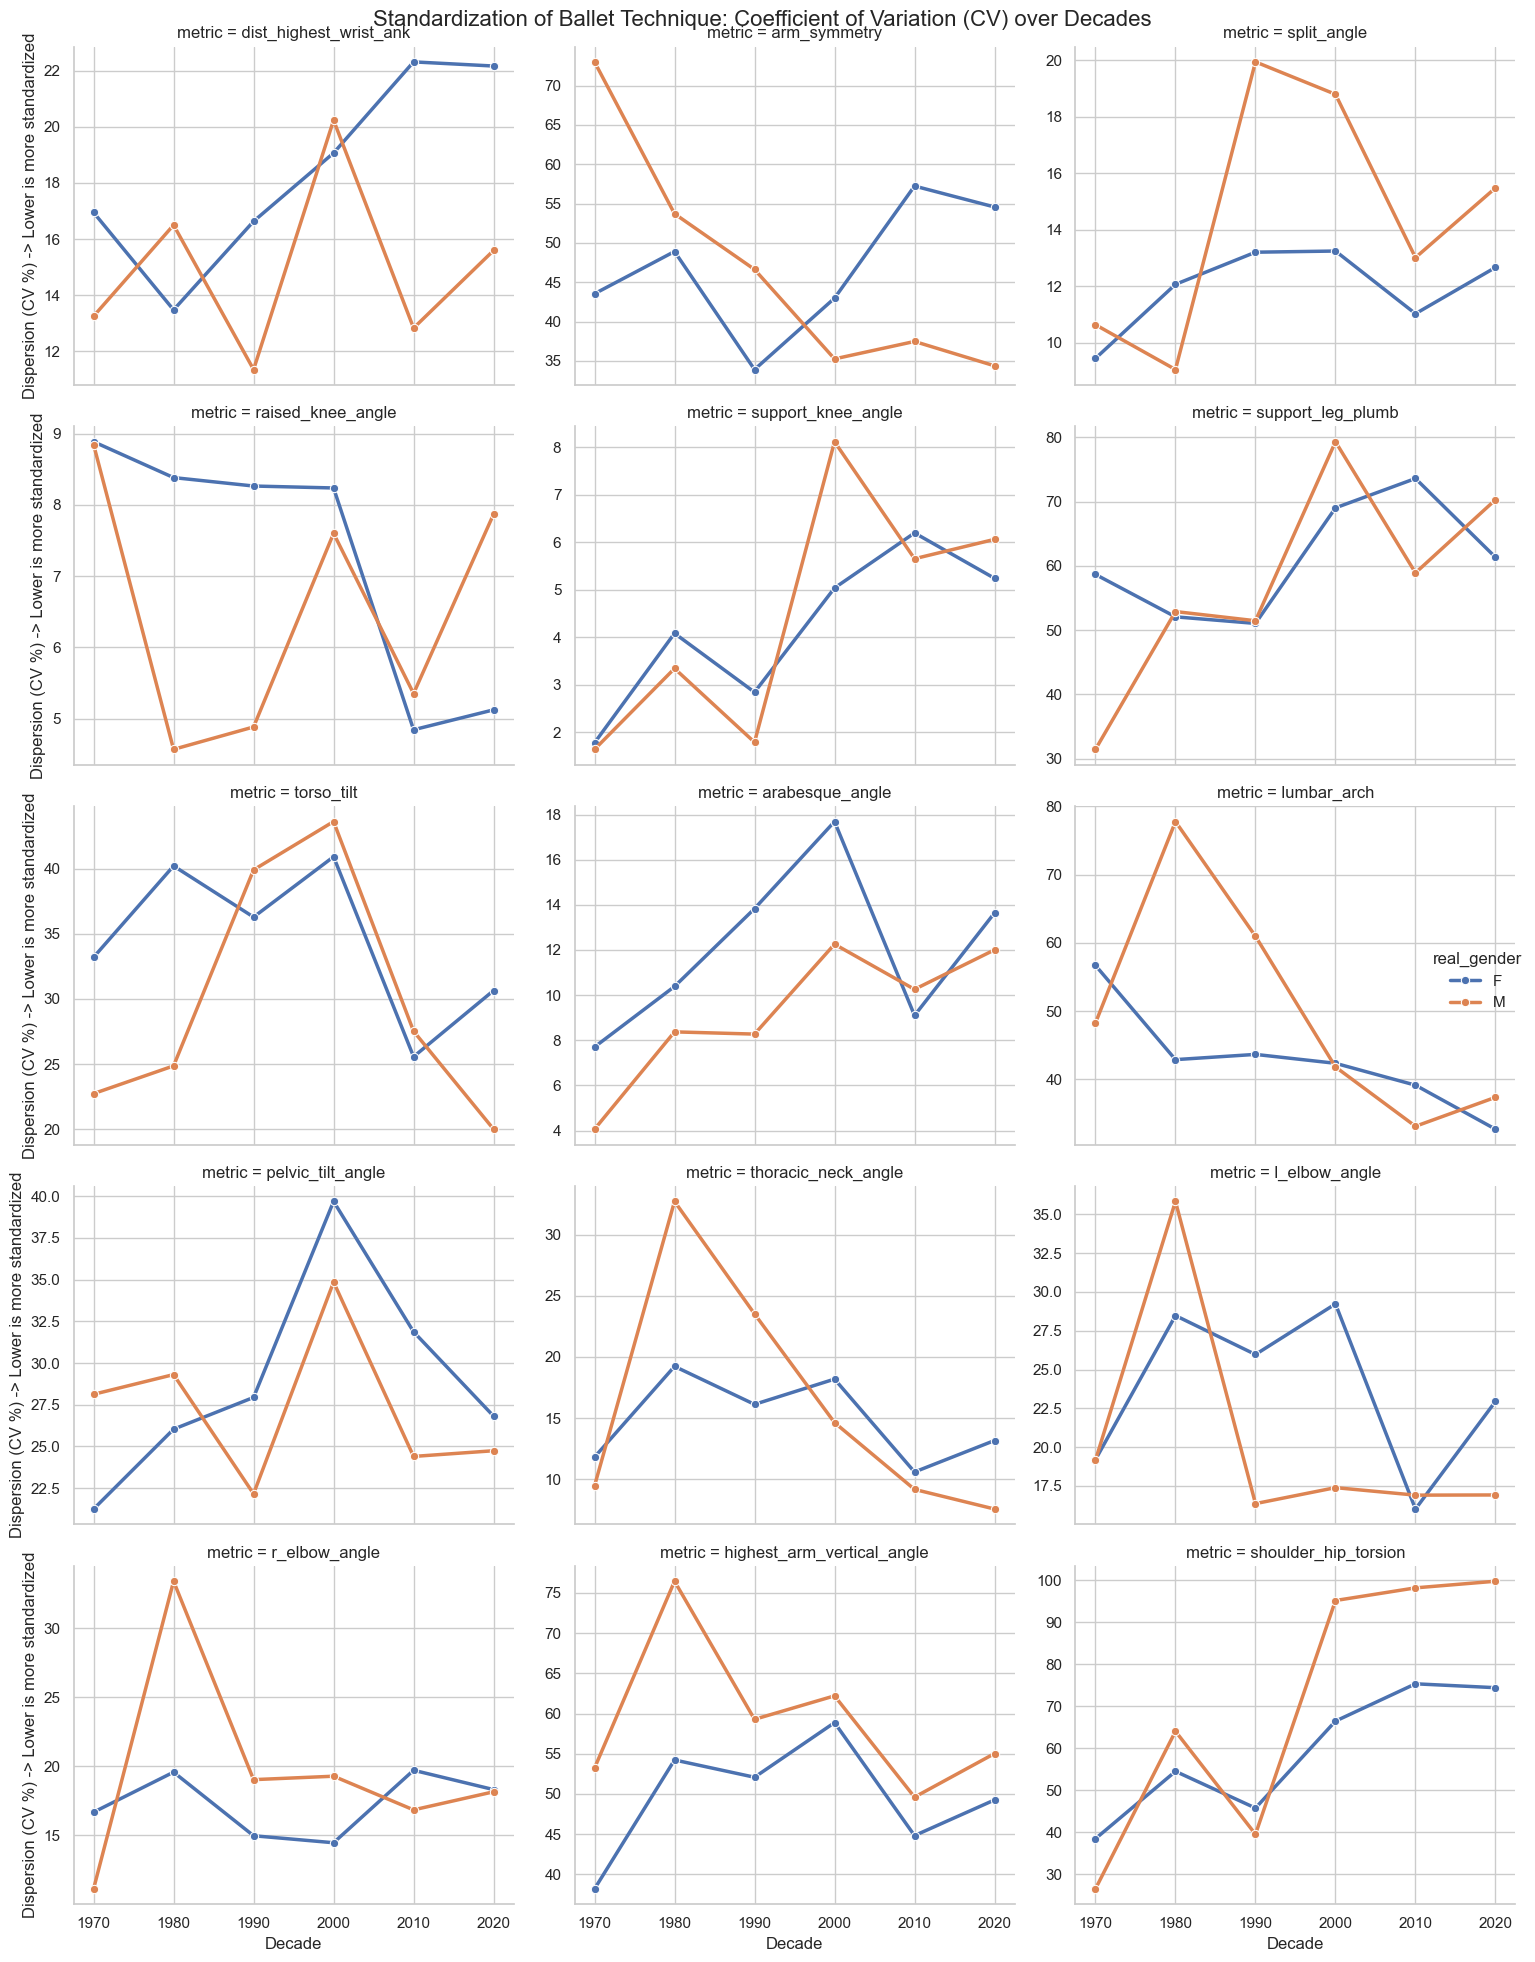


📊 Levene's Test (Variance):
[F] feature: dist_highest_wrist_ank | p-value: 0.2546 ns  | No Significant Difference
[M] feature: dist_highest_wrist_ank | p-value: 0.7191 ns  | No Significant Difference
[F] feature: arm_symmetry         | p-value: 0.5346 ns  | No Significant Difference
[M] feature: arm_symmetry         | p-value: 0.0168 *   | ✅ Significant Converged (Variance: 0.2 -> 0.0)
[F] feature: split_angle          | p-value: 0.0344 *   | ❌ Significant Diverged (Variance: 77.4 -> 176.0)
[M] feature: split_angle          | p-value: 0.0987 ns  | No Significant Difference
[F] feature: raised_knee_angle    | p-value: 0.3576 ns  | No Significant Difference
[M] feature: raised_knee_angle    | p-value: 0.4453 ns  | No Significant Difference
[F] feature: support_knee_angle   | p-value: 0.0000 *** | ❌ Significant Diverged (Variance: 8.9 -> 70.1)
[M] feature: support_knee_angle   | p-value: 0.0063 **  | ❌ Significant Diverged (Variance: 7.6 -> 93.5)
[F] feature: support_leg_plumb    | p-val

In [9]:
warnings.filterwarnings('ignore')
# ==========================================
# CV
# ==========================================
def calculate_cv(x):
    mean_val = x.mean()
    return (x.std() / mean_val) * 100 if mean_val != 0 else 0 

cv_df = df.groupby(['decade', 'real_gender'])[feature_cols].agg(calculate_cv).reset_index()

cv_melted = cv_df.melt(
    id_vars=['decade', 'real_gender'], 
    value_vars=feature_cols,
    var_name='metric', 
    value_name='CV (%)'
)

sns.set_theme(style="whitegrid")
g = sns.FacetGrid(cv_melted, col="metric", col_wrap=3, hue="real_gender", height=4, aspect=1.2, sharey=False)
g.map(sns.lineplot, "decade", "CV (%)", marker="o", linewidth=2.5)
g.add_legend()
g.set_axis_labels("Decade", "Dispersion (CV %) -> Lower is more standardized")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('Standardization of Ballet Technique: Coefficient of Variation (CV) over Decades', fontsize=16)
plt.tight_layout()
plt.show()


# ==========================================
# 2. Levene's Test
# ==========================================
print("\n" + "="*60)
print("📊 Levene's Test (Variance):")
print("="*60)

decade_start = df['decade'].min()
decade_end = df['decade'].max()

for metric in feature_cols:
    for gender in ['F', 'M']:
        data_start = df[(df['real_gender'] == gender) & (df['decade'] == decade_start)][metric].dropna()
        data_end = df[(df['real_gender'] == gender) & (df['decade'] == decade_end)][metric].dropna()
        
        if len(data_start) < 5 or len(data_end) < 5:
            continue
            
        stat, p_value = stats.levene(data_start, data_end, center='median')
        
        var_start = np.var(data_start, ddof=1)
        var_end = np.var(data_end, ddof=1)
        
        if p_value < 0.05:
            if var_end < var_start:
                trend = f"✅ Significant Converged (Variance: {var_start:.1f} -> {var_end:.1f})"
            else:
                trend = f"❌ Significant Diverged (Variance: {var_start:.1f} -> {var_end:.1f})"
            sig = "***" if p_value < 0.001 else ("**" if p_value < 0.01 else "*")
        else:
            trend = f"No Significant Difference"
            sig = "ns"

        print(f"[{gender}] feature: {metric.ljust(20)} | p-value: {p_value:.4f} {sig.ljust(3)} | {trend}")

📊 Multivariate Spatial Discreteness Analysis (High-dimensional Euclidean distance)

----- F -----
  1970 - Mean Euclidean distance: 1.960
  1980 - Mean Euclidean distance: 2.122
  1990 - Mean Euclidean distance: 2.165
  2000 - Mean Euclidean distance: 2.647
  2010 - Mean Euclidean distance: 2.420
  2020 - Mean Euclidean distance: 2.602

----- M -----
  1970 - Mean Euclidean distance: 1.631
  1980 - Mean Euclidean distance: 2.388
  1990 - Mean Euclidean distance: 2.444
  2000 - Mean Euclidean distance: 2.690
  2010 - Mean Euclidean distance: 2.175
  2020 - Mean Euclidean distance: 2.495


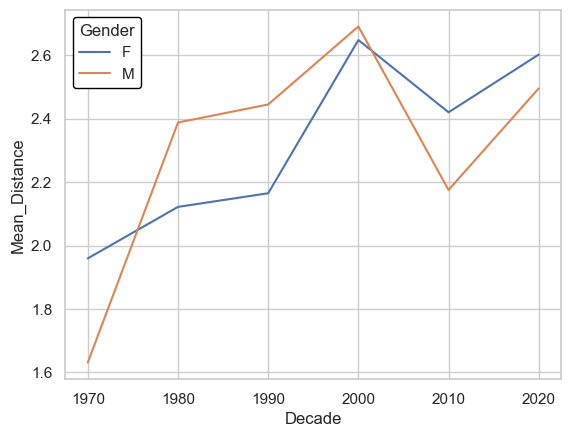

In [10]:
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[target_metrics] = scaler.fit_transform(df[target_metrics])

print("="*60)
print("📊 Multivariate Spatial Discreteness Analysis (High-dimensional Euclidean distance)")
print("="*60)

results = []

for gender in ['F', 'M']:
    print(f"\n----- {gender} -----")
    
    for decade in sorted(df_scaled['decade'].unique()):
        group = df_scaled[(df_scaled['real_gender'] == gender) & (df_scaled['decade'] == decade)]
        
        if len(group) < 5: continue
        
        matrix = group[target_metrics].values
        
        centroid = np.mean(matrix, axis=0)
        
        distances = [euclidean(row, centroid) for row in matrix]
        
        mean_distance = np.mean(distances)
        results.append({'Gender': gender, 'Decade': decade, 'Mean_Distance': mean_distance})
        
        print(f"  {decade} - Mean Euclidean distance: {mean_distance:.3f}")

df_results = pd.DataFrame(results)
sns.lineplot(data=df_results, x='Decade', y='Mean_Distance', hue='Gender')
plt.legend(facecolor='white', framealpha=1.0, edgecolor='black', title='Gender')
plt.show()

In [11]:
baseline_year = int(df_scaled['year'].min())
df_scaled['year_centered'] = df_scaled['year'] - baseline_year
df_scaled['real_gender'] = pd.Categorical(df_scaled['real_gender'], categories=['F', 'M'], ordered=True)

print("="*70)
print("📊 Multivariate Spatial Discreteness Test")
print("="*70)

distances_list = []

for (gender, decade), group in df_scaled.groupby(['real_gender', 'decade']):
    if len(group) < 5:
        distances_list.extend([np.nan] * len(group))
        continue
        
    matrix = group[target_metrics].values
    centroid = np.mean(matrix, axis=0) 
    
    distances = [euclidean(row, centroid) for row in matrix]
    distances_list.extend(distances)

df_scaled['centroid_distance'] = pd.Series(
    distances_list, 
    index=df_scaled.groupby(['real_gender', 'decade']).indices_to_index() 
    if hasattr(df_scaled.groupby(['real_gender', 'decade']), 'indices_to_index') 
    else [idx for _, group in df_scaled.groupby(['real_gender', 'decade']) for idx in group.index]
)

df_scaled['centroid_distance'] = np.nan
for (gender, decade), group in df_scaled.groupby(['real_gender', 'decade']):
    if len(group) >= 5:
        matrix = group[target_metrics].values
        centroid = np.mean(matrix, axis=0)
        dist = [euclidean(row, centroid) for row in matrix]
        df_scaled.loc[group.index, 'centroid_distance'] = dist

formula = 'centroid_distance ~ year_centered * C(real_gender)'

try:
    mod_dispersion = smf.ols(formula, data=df_scaled.dropna(subset=['centroid_distance', 'year_centered', 'real_gender']))
    res_dispersion = mod_dispersion.fit()
    
    print(res_dispersion.summary())
    
    print("\n***Core Interpretations***")
    
    p_year_F = res_dispersion.pvalues['year_centered']
    p_interaction = res_dispersion.pvalues['year_centered:C(real_gender)[T.M]']
    coef_year_F = res_dispersion.params['year_centered']
    
    if p_year_F < 0.05 and coef_year_F > 0:
        print(f"1. [Diversity Divergence]: Significant (p={p_year_F:.4f})")
        print("As the years go by, the high-dimensional centroid distance for the female dancers (reference group) has been increasing significantly.")
    
    if p_interaction < 0.05:
        print(f"\n2. [Gender Diff]: Significant (p={p_interaction:.4f})")
        print("   There is a fundamental difference between male and female in the rate at which they diversify.")
    else:
        print(f"\n2. [Gender Diff]: NOT Significant (p={p_interaction:.4f})")
        print("   There is no fundamental difference between male and female in the rate at which they diversify.")

except Exception as e:
    print(f"OLS Error: {e}")

📊 Multivariate Spatial Discreteness Test
                            OLS Regression Results                            
Dep. Variable:      centroid_distance   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     12.89
Date:                Sat, 23 May 2026   Prob (F-statistic):           3.27e-08
Time:                        19:02:47   Log-Likelihood:                -858.29
No. Observations:                 735   AIC:                             1725.
Df Residuals:                     731   BIC:                             1743.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------


📊 PCA
----- F -----
The first two principal components account for 30.8% and 21.5% difference.

[Loadings]:
                           PC1       PC2
split_angle           0.337093 -0.438753
support_leg_plumb     0.496831  0.780184
torso_tilt            0.381661 -0.286052
arabesque_angle      -0.374406  0.155672
lumbar_arch           0.005845 -0.066929
pelvic_tilt_angle     0.482413 -0.246703
thoracic_neck_angle   0.278501  0.051679
shoulder_hip_torsion -0.208238 -0.157282
----- M -----
The first two principal components account for 39.0% and 25.6% difference.

[Loadings]:
                           PC1       PC2
split_angle          -0.513059  0.335879
support_leg_plumb     0.660447  0.620349
torso_tilt            0.059805  0.048532
arabesque_angle       0.248533 -0.532284
lumbar_arch          -0.393965 -0.007077
pelvic_tilt_angle    -0.260922  0.305896
thoracic_neck_angle  -0.076570  0.050898
shoulder_hip_torsion  0.077996 -0.347069


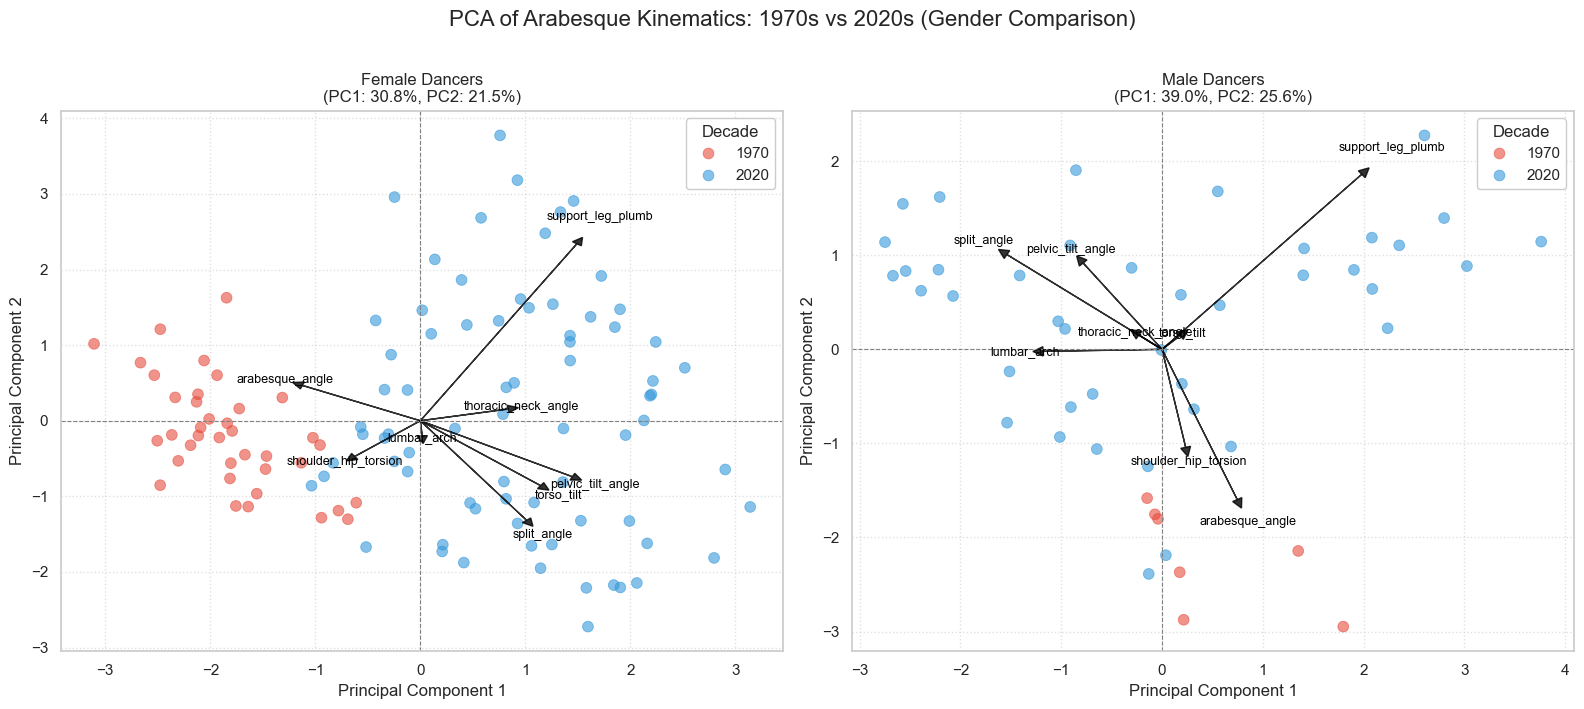

In [12]:
print("\n" + "="*60)
print("📊 PCA")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('PCA of Arabesque Kinematics: 1970s vs 2020s (Gender Comparison)', fontsize=16, y=1.01)

genders = ['F', 'M']
titles = ['Female Dancers', 'Male Dancers']

for i, gender in enumerate(genders):
    print(f"----- {gender} -----")
    ax = axes[i]
    
    df_g = df_scaled[(df_scaled['real_gender'] == gender) & (df_scaled['decade'].isin(['1970', '2020']))].copy()

    if isinstance(df_g['decade'].dtype, pd.CategoricalDtype):
        df_g['decade'] = df_g['decade'].cat.remove_unused_categories()

    X_g = df_g[target_metrics].values
    
    pca = PCA(n_components=2)
    components = pca.fit_transform(X_g)
    df_g['PC1'] = components[:, 0]
    df_g['PC2'] = components[:, 1]
    
    explained_var = pca.explained_variance_ratio_
    print(f"The first two principal components account for {explained_var[0]*100:.1f}% and {explained_var[1]*100:.1f}% difference.")

    loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=target_metrics)
    print("\n[Loadings]:")
    print(loadings)
    
    sns.scatterplot(
        data=df_g, x='PC1', y='PC2', 
        hue='decade', palette=['#e74c3c', '#3498db'], 
        hue_order=['1970', '2020'],
        alpha=0.6, s=60, ax=ax, edgecolor=None
    )
    
    loadings = pca.components_.T
    for j, feature in enumerate(target_metrics):
        arrow_x = loadings[j, 0] * 3 
        arrow_y = loadings[j, 1] * 3
        
        ax.arrow(0, 0, arrow_x, arrow_y, color='black', alpha=0.8, head_width=0.1, head_length=0.1)
        ax.text(arrow_x * 1.15, arrow_y * 1.15, feature, color='black', ha='center', va='center', fontsize=9)
    
    ax.set_title(f"{titles[i]}\n(PC1: {explained_var[0]*100:.1f}%, PC2: {explained_var[1]*100:.1f}%)")
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    ax.legend(title='Decade', facecolor='white', framealpha=1)

plt.tight_layout()
plt.show()

#### Generational Transition in Driving Mechanisms (Evolution of Correlations)

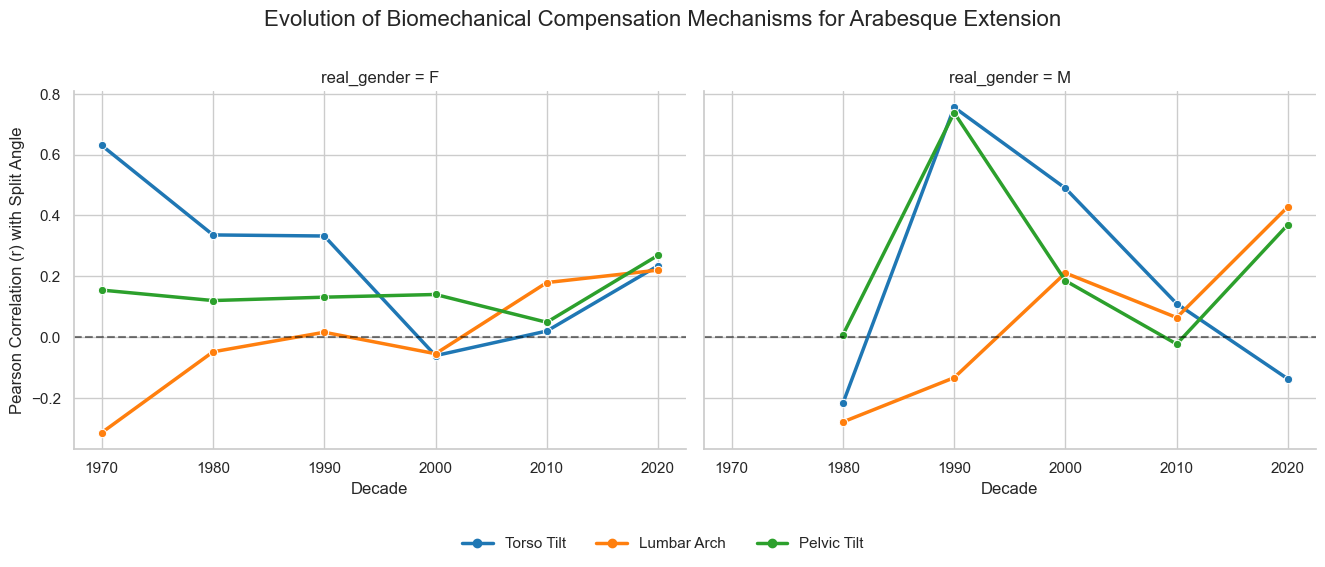

In [13]:
compensatory_metrics = {
    'torso_tilt': 'Torso Tilt',
    'lumbar_arch': 'Lumbar Arch',
    'pelvic_tilt_angle': 'Pelvic Tilt'
}

corr_records = []
for (decade, gender), group in df.groupby(['decade', 'real_gender']):
    if len(group) > 10:
        for metric, name in compensatory_metrics.items():
            r = group['split_angle'].corr(group[metric])
            corr_records.append({
                'decade': decade,
                'real_gender': gender,
                'metric_name': name,
                'correlation': r
            })

corr_df = pd.DataFrame(corr_records)

sns.set_theme(style="whitegrid")
g = sns.relplot(
    data=corr_df,
    x="decade",
    y="correlation",
    col="real_gender",
    hue="metric_name",
    kind="line",
    marker="o",
    linewidth=2.5,
    height=5, 
    aspect=1.2,
    palette="tab10" 
)

for ax in g.axes.flat:
    ax.axhline(0, color="black", linestyle="--", alpha=0.5)

sns.move_legend(
    g, 
    "lower center",              
    bbox_to_anchor=(0.5, -0.1), 
    ncol=3,                      
    title=None,                   
    frameon=False                
)
g.set_axis_labels("Decade", "Pearson Correlation (r) with Split Angle")
g.fig.suptitle('Evolution of Biomechanical Compensation Mechanisms for Arabesque Extension', y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

#### Analysis of Motion Extremes

📊 Extremes Analysis for: split_angle
   decade real_gender        Mean  Top_10_Percent_Max
0    1970           F   93.104630          104.135746
1    1970           M   83.981124           93.200331
2    1980           F   95.708727          110.239258
3    1980           M   92.697647          102.873625
4    1990           F  106.414282          126.509435
5    1990           M   87.420928          112.082757
6    2000           F  106.898965          125.426499
7    2000           M   94.485844          115.228304
8    2010           F  104.108690          117.241194
9    2010           M   98.900308          116.262898
10   2020           F  104.729750          120.471251
11   2020           M   96.788900          119.178244


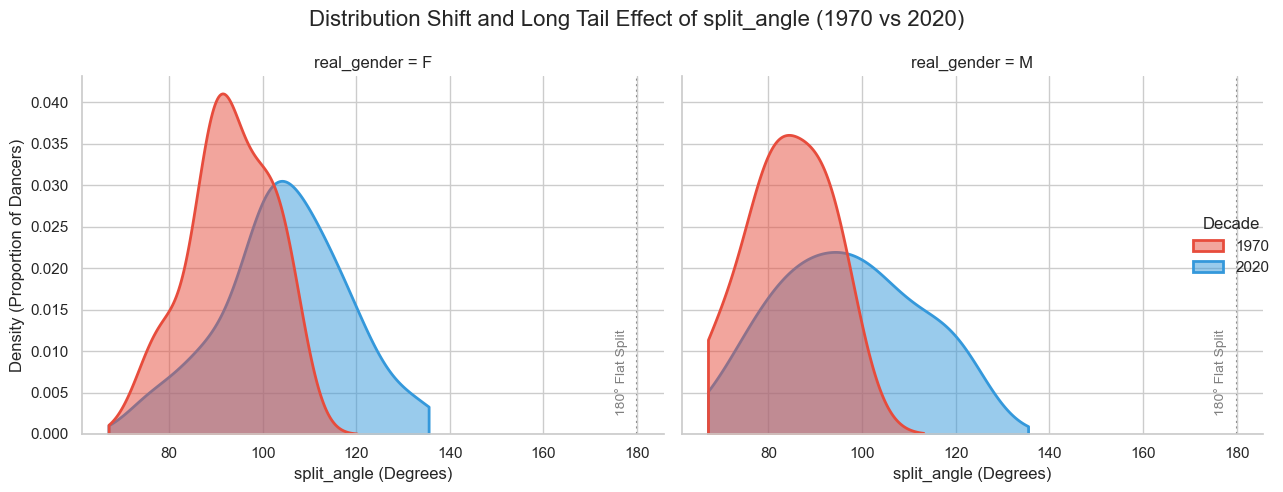

📊 Extremes Analysis for: support_leg_plumb
   decade real_gender       Mean  Top_10_Percent_Max
0    1970           F   5.849733            8.627795
1    1970           M   7.853982           10.049612
2    1980           F   6.987293           10.799980
3    1980           M   7.558706           11.602027
4    1990           F   6.745079           11.312128
5    1990           M   7.133675           12.567958
6    2000           F  11.142443           23.196654
7    2000           M  10.885675           21.402543
8    2010           F  13.248748           27.465923
9    2010           M  11.186798           19.607893
10   2020           F  18.859706           33.316740
11   2020           M  18.020128           35.981540


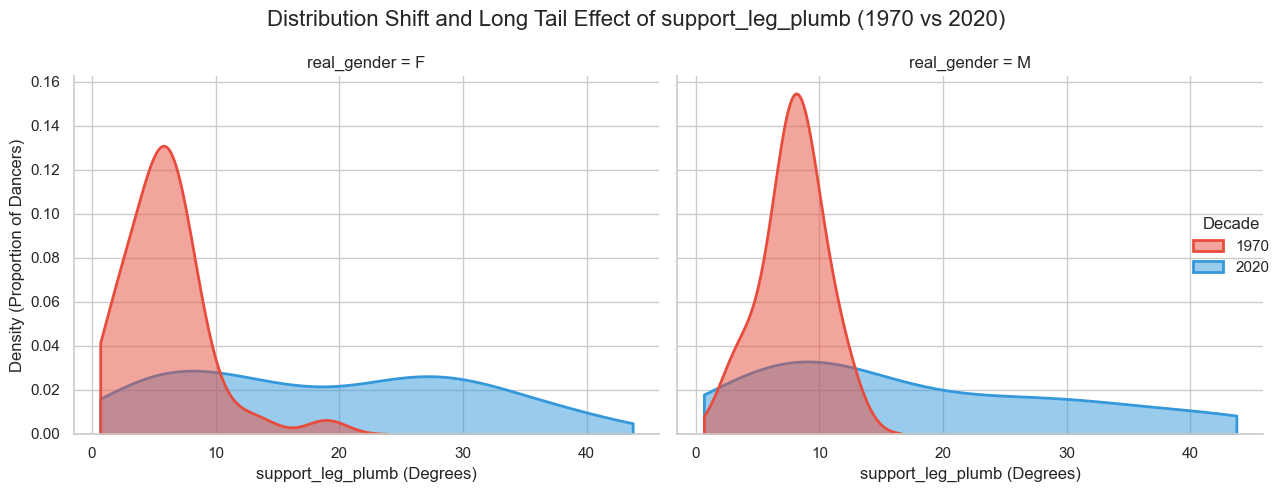

📊 Extremes Analysis for: torso_tilt
   decade real_gender       Mean  Top_10_Percent_Max
0    1970           F  19.089530           26.097142
1    1970           M  22.215665           28.619590
2    1980           F  14.822957           22.898147
3    1980           M  18.765439           25.688878
4    1990           F  15.588032           22.060546
5    1990           M  19.478603           28.793684
6    2000           F  17.884491           27.981829
7    2000           M  20.629440           35.339558
8    2010           F  25.025900           32.750302
9    2010           M  24.023568           32.106025
10   2020           F  26.187767           36.612558
11   2020           M  24.918199           32.124851


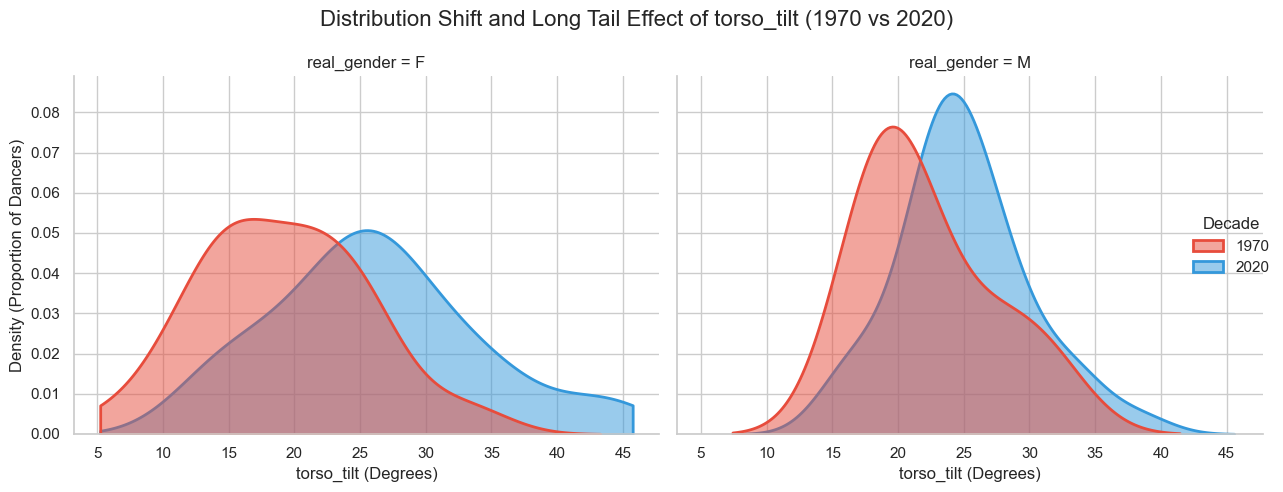

📊 Extremes Analysis for: arabesque_angle
   decade real_gender        Mean  Top_10_Percent_Max
0    1970           F  103.653473          114.423652
1    1970           M  114.576581          119.938302
2    1980           F   94.767725          106.606861
3    1980           M  104.229715          116.992683
4    1990           F   85.565937          100.736766
5    1990           M  105.831338          115.623835
6    2000           F   85.554337          102.042181
7    2000           M  100.556914          117.522497
8    2010           F   95.877932          106.305184
9    2010           M  102.365607          114.856191
10   2020           F   90.299779          105.647753
11   2020           M   97.381132          112.908561


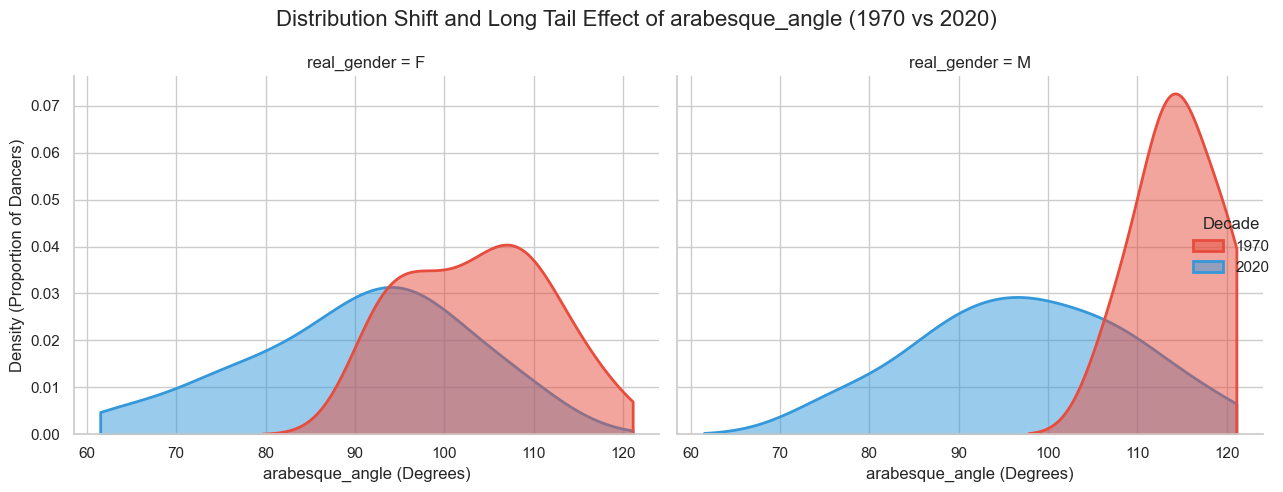

📊 Extremes Analysis for: lumbar_arch
   decade real_gender       Mean  Top_10_Percent_Max
0    1970           F  20.683006           33.908668
1    1970           M  21.147240           30.294671
2    1980           F  19.845235           30.189925
3    1980           M  14.368880           27.152315
4    1990           F  21.879683           32.980374
5    1990           M  18.018887           28.834843
6    2000           F  22.919124           32.726562
7    2000           M  24.213412           35.816010
8    2010           F  24.093822           37.136396
9    2010           M  25.353760           35.375517
10   2020           F  23.109783           32.483337
11   2020           M  23.681221           34.504908


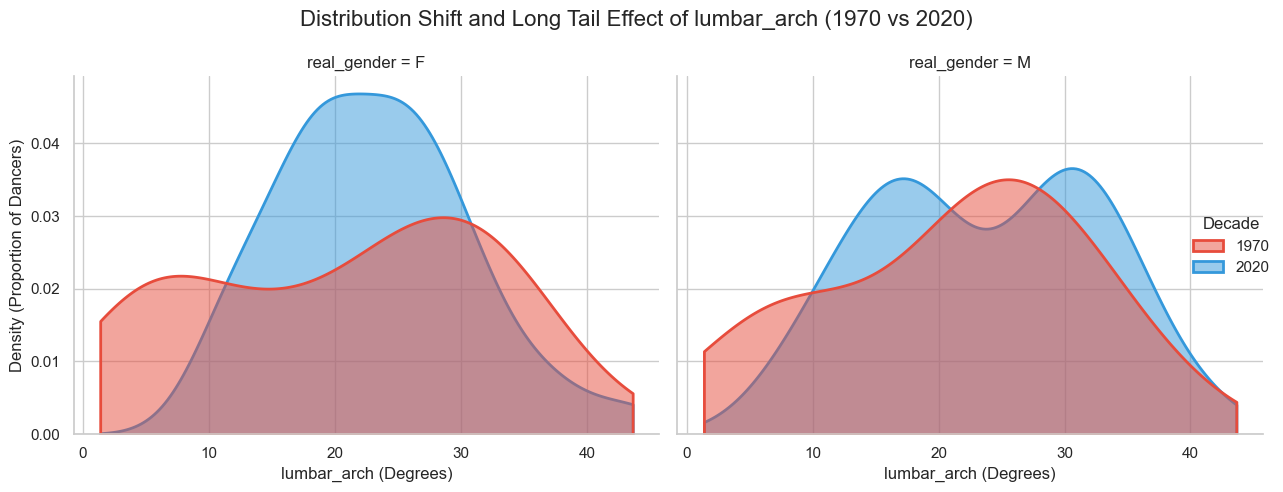

📊 Extremes Analysis for: pelvic_tilt_angle
   decade real_gender       Mean  Top_10_Percent_Max
0    1970           F  22.530526           28.932507
1    1970           M  20.242919           25.370115
2    1980           F  20.205710           25.572914
3    1980           M  19.019852           24.699388
4    1990           F  19.368637           25.621669
5    1990           M  21.993829           27.259747
6    2000           F  22.613303           33.180897
7    2000           M  24.694456           34.890920
8    2010           F  27.161854           39.755118
9    2010           M  29.974026           38.326110
10   2020           F  32.278620           42.673694
11   2020           M  30.672922           38.258932


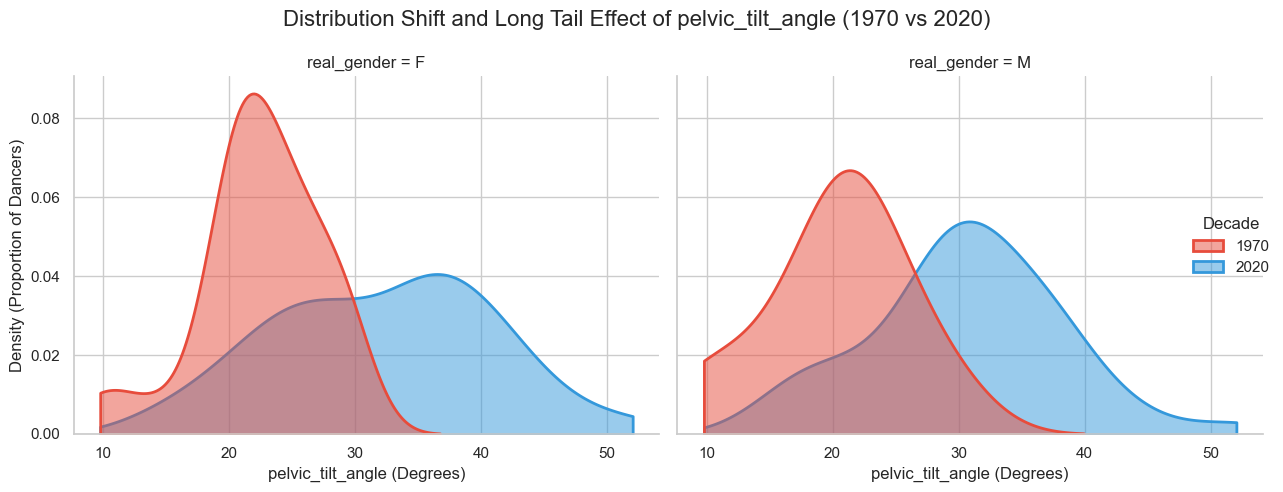

📊 Extremes Analysis for: thoracic_neck_angle
   decade real_gender        Mean  Top_10_Percent_Max
0    1970           F   82.120913           92.624861
1    1970           M   96.085717          104.643337
2    1980           F   83.006257           99.112931
3    1980           M   74.463090           96.598640
4    1990           F   82.314422           97.575215
5    1990           M   73.900915           91.321481
6    2000           F   84.051838          103.885162
7    2000           M   99.817237          111.207577
8    2010           F   99.635907          111.910809
9    2010           M  102.888474          114.208326
10   2020           F   98.173294          111.947732
11   2020           M  102.142592          110.451758


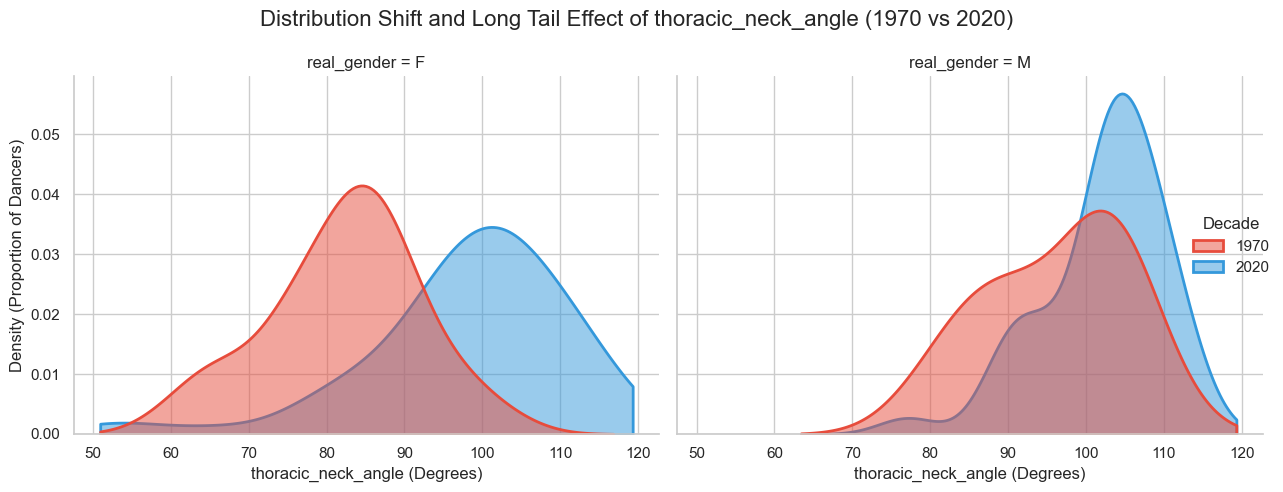

📊 Extremes Analysis for: shoulder_hip_torsion
   decade real_gender       Mean  Top_10_Percent_Max
0    1970           F  33.153489           46.316727
1    1970           M  37.779822           47.036148
2    1980           F  37.329479           59.396250
3    1980           M  36.316153           59.188465
4    1990           F  35.251684           57.077746
5    1990           M  42.278029           63.603810
6    2000           F  28.495633           52.578272
7    2000           M  16.552285           39.039518
8    2010           F  22.740589           45.285842
9    2010           M  16.657303           40.458687
10   2020           F  17.525344           31.124592
11   2020           M  13.622856           37.722712


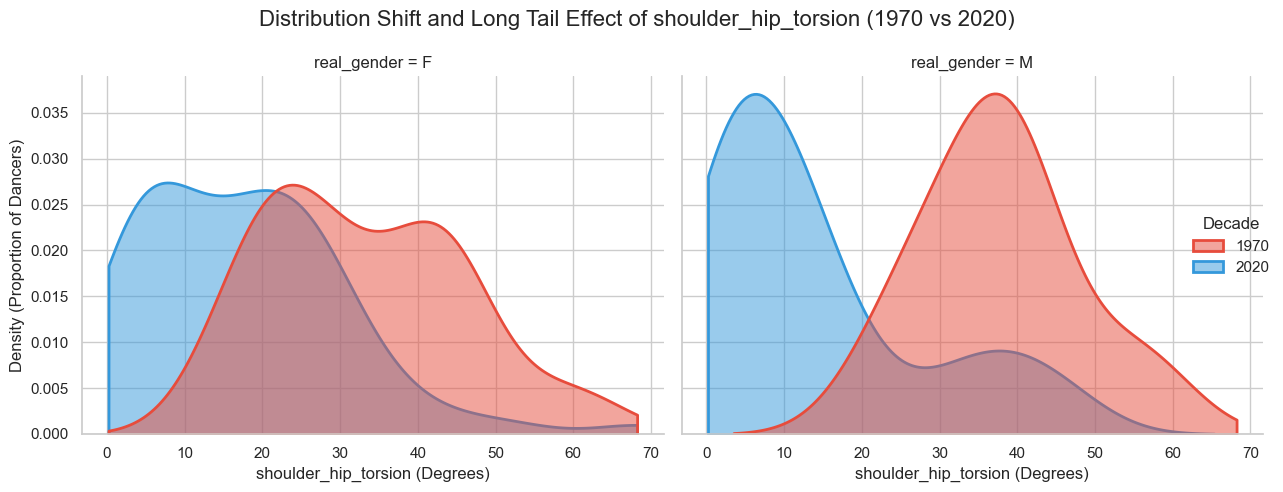

In [14]:
target_metrics = [
    'split_angle', 
    'support_leg_plumb', 
    'torso_tilt', 
    'arabesque_angle', 
    'lumbar_arch', 
    'pelvic_tilt_angle',
    'thoracic_neck_angle', 
    'shoulder_hip_torsion'  
]

start_decade = df['decade'].min()
end_decade = df['decade'].max()

df_extremes = df[df['decade'].isin([start_decade, end_decade])]

for metric in target_metrics:
    print("="*60)
    print(f"📊 Extremes Analysis for: {metric}")
    print("="*60)

    df_clean = df.dropna(subset=[metric])
    extreme_stats = df_clean.groupby(['decade', 'real_gender'])[metric].agg(
        Mean='mean',
        Top_10_Percent_Max=lambda x: np.percentile(x, 90)
    ).reset_index()

    print(extreme_stats)

    # ==========================================
    # KDE Distribution (Long Tail)
    # ==========================================
    sns.set_theme(style="whitegrid")

    min_val = df_extremes[metric].min()
    max_val = df_extremes[metric].max()

    g = sns.displot(
        data=df_extremes.dropna(subset=[metric]),
        x=metric, 
        hue="decade",          
        hue_order=[start_decade, end_decade],
        col="real_gender",           
        kind="kde",               
        palette=["#e74c3c", "#3498db"], 
        fill=True, 
        alpha=0.5, 
        linewidth=2,
        common_norm=False,       
        height=5, 
        aspect=1.2,
        clip=(min_val, max_val)
    )

    if metric == 'split_angle':
        for ax in g.axes.flat:
            ax.axvline(180, color='gray', linestyle=':', zorder=0)
            y_pos = ax.get_ylim()[1] * 0.05
            ax.text(178, y_pos, '180° Flat Split', color='gray', rotation=90, 
                    verticalalignment='bottom', horizontalalignment='right', fontsize=10)

    g.set_axis_labels(f"{metric} (Degrees)", "Density (Proportion of Dancers)")
    g._legend.set_title("Decade")
    g.fig.suptitle(f'Distribution Shift and Long Tail Effect of {metric} ({start_decade} vs {end_decade})', fontsize=16)

    plt.tight_layout()
    plt.show()

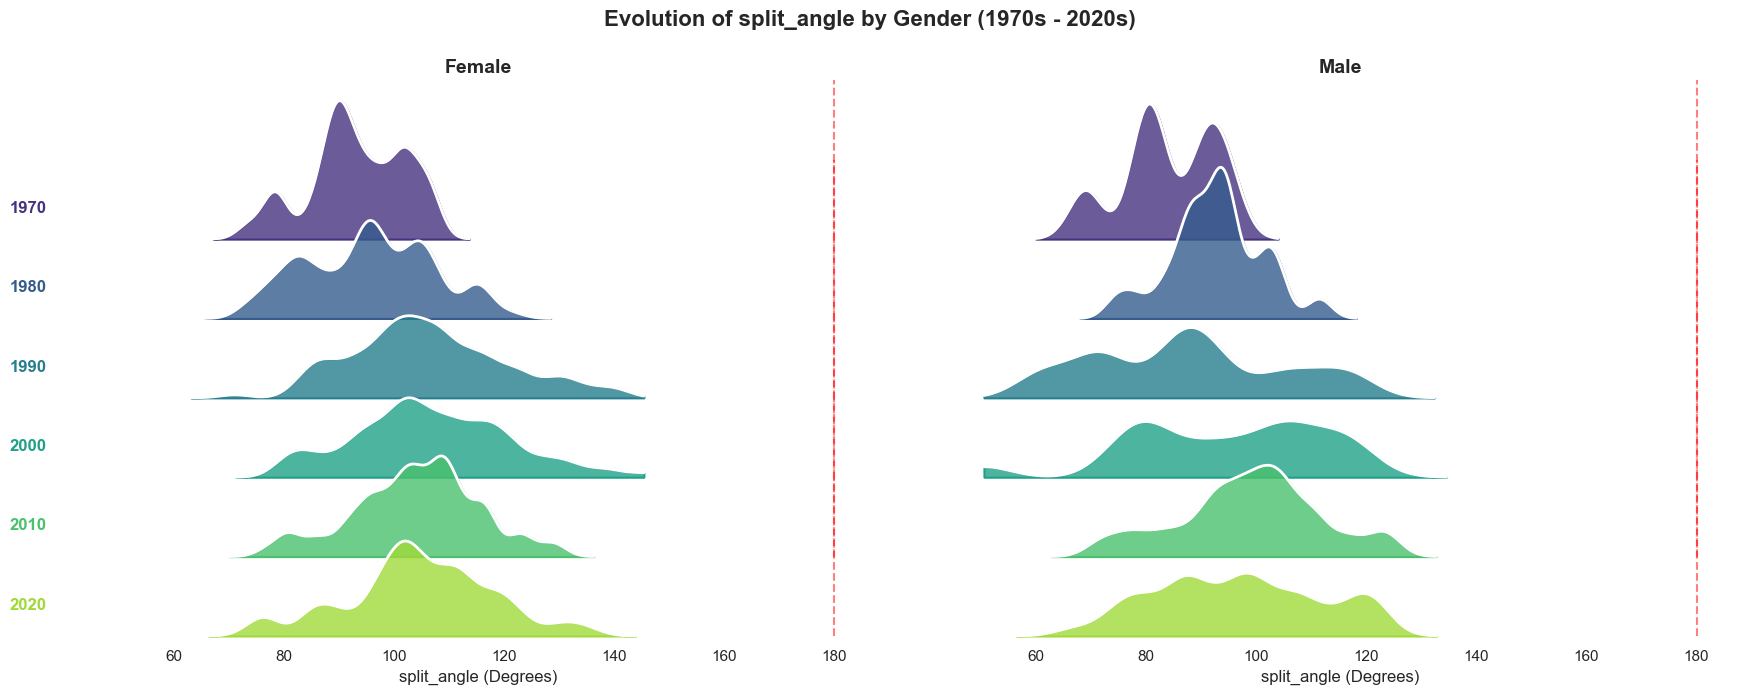

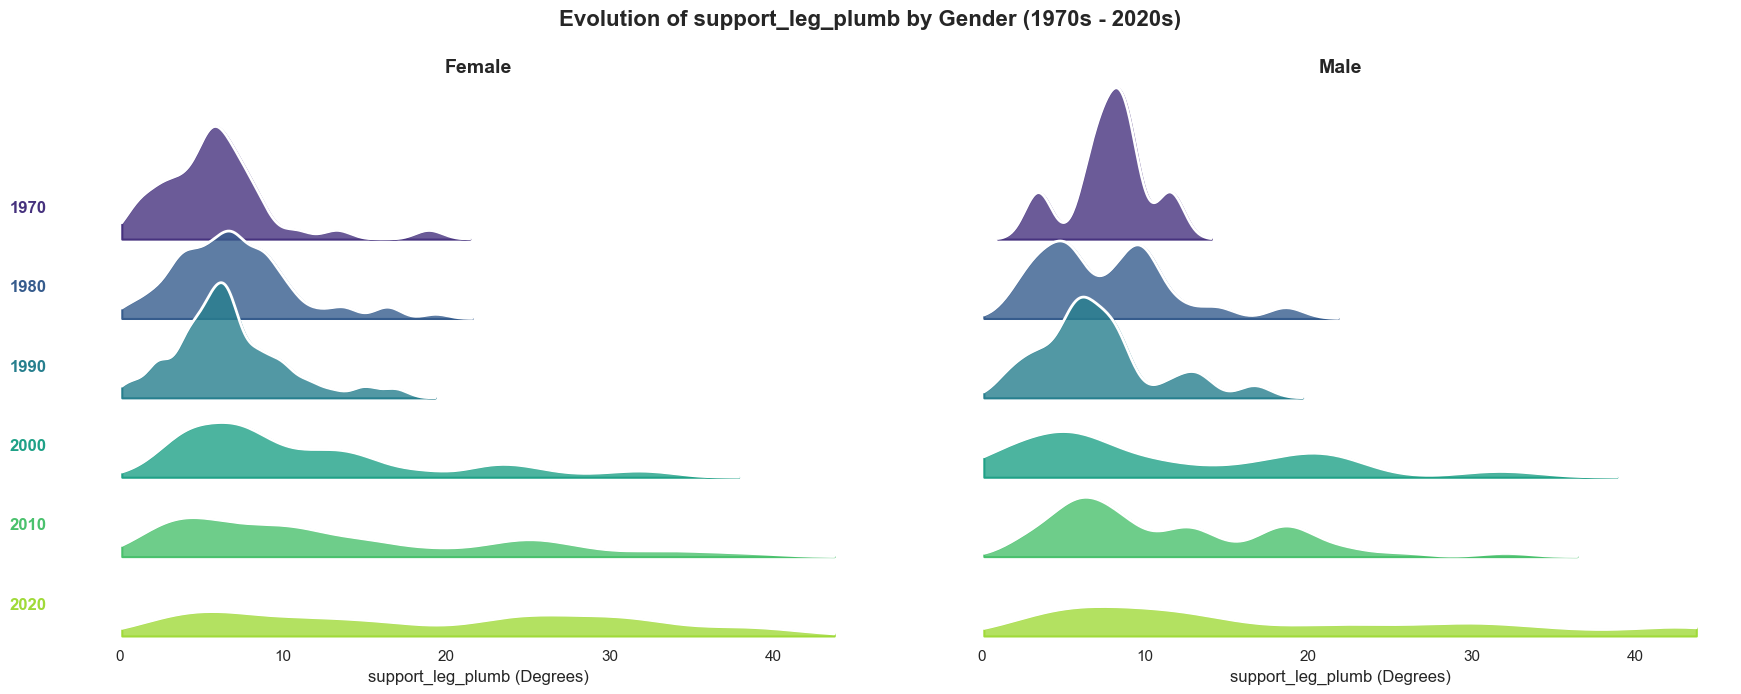

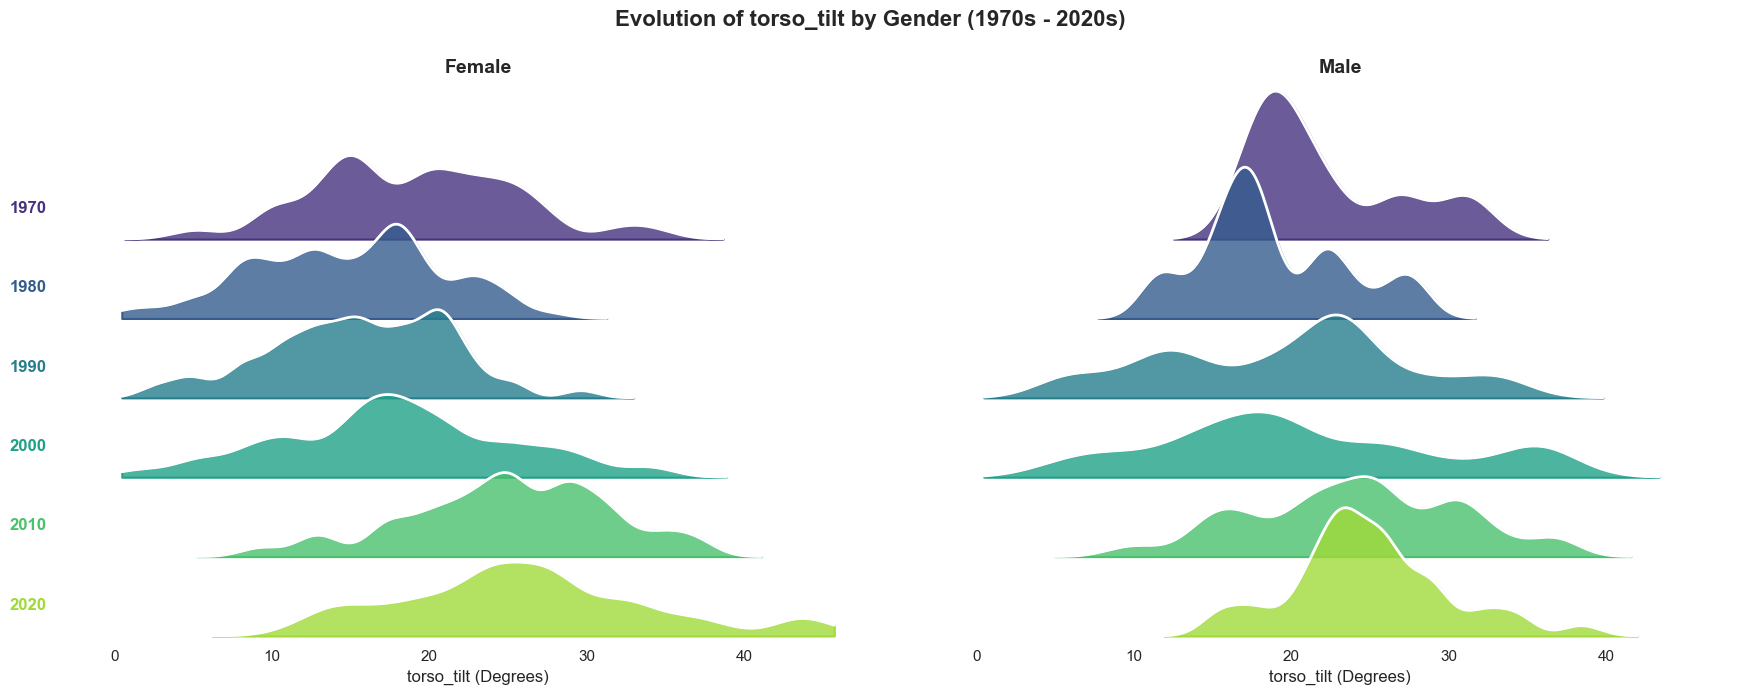

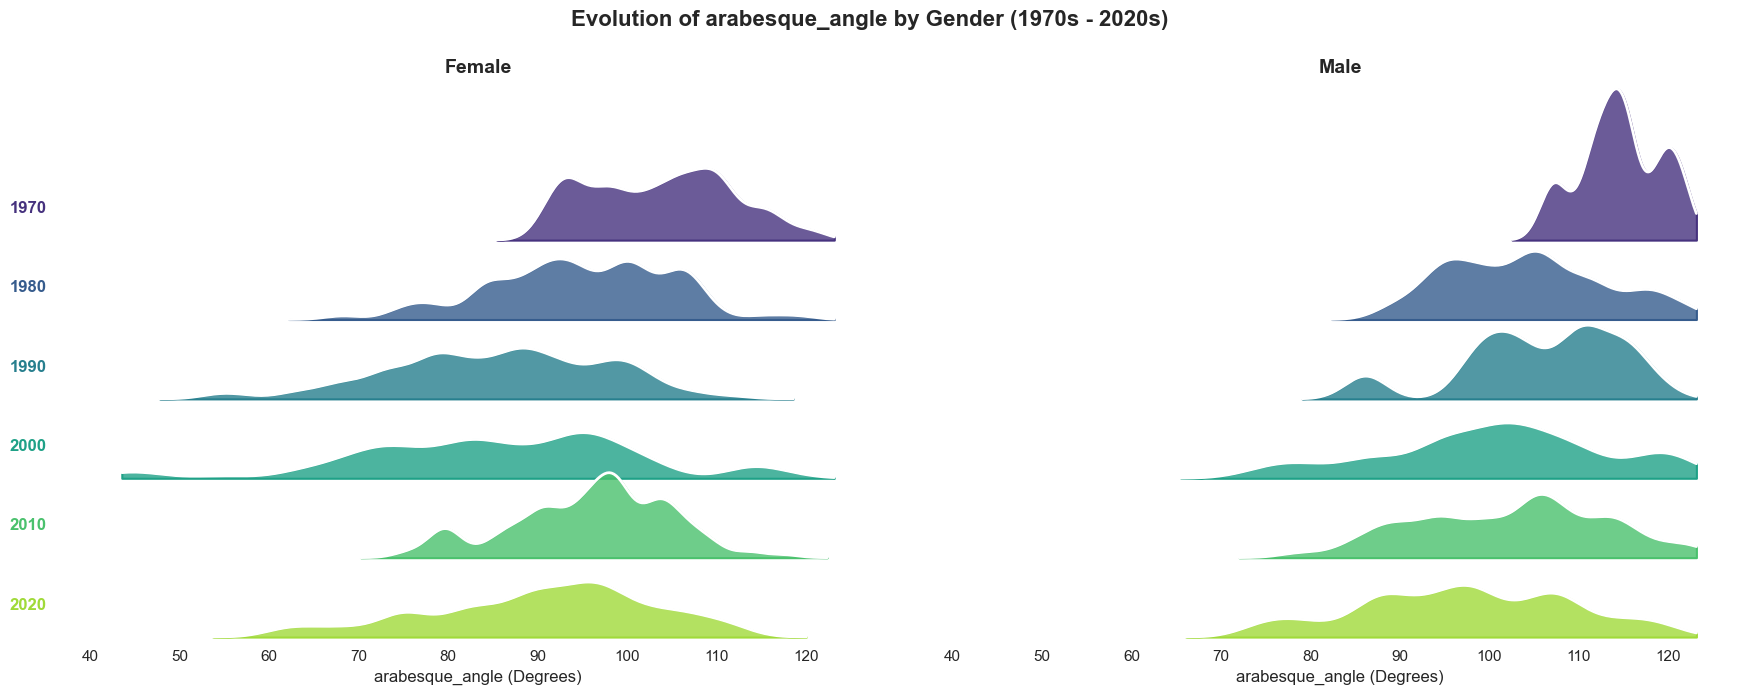

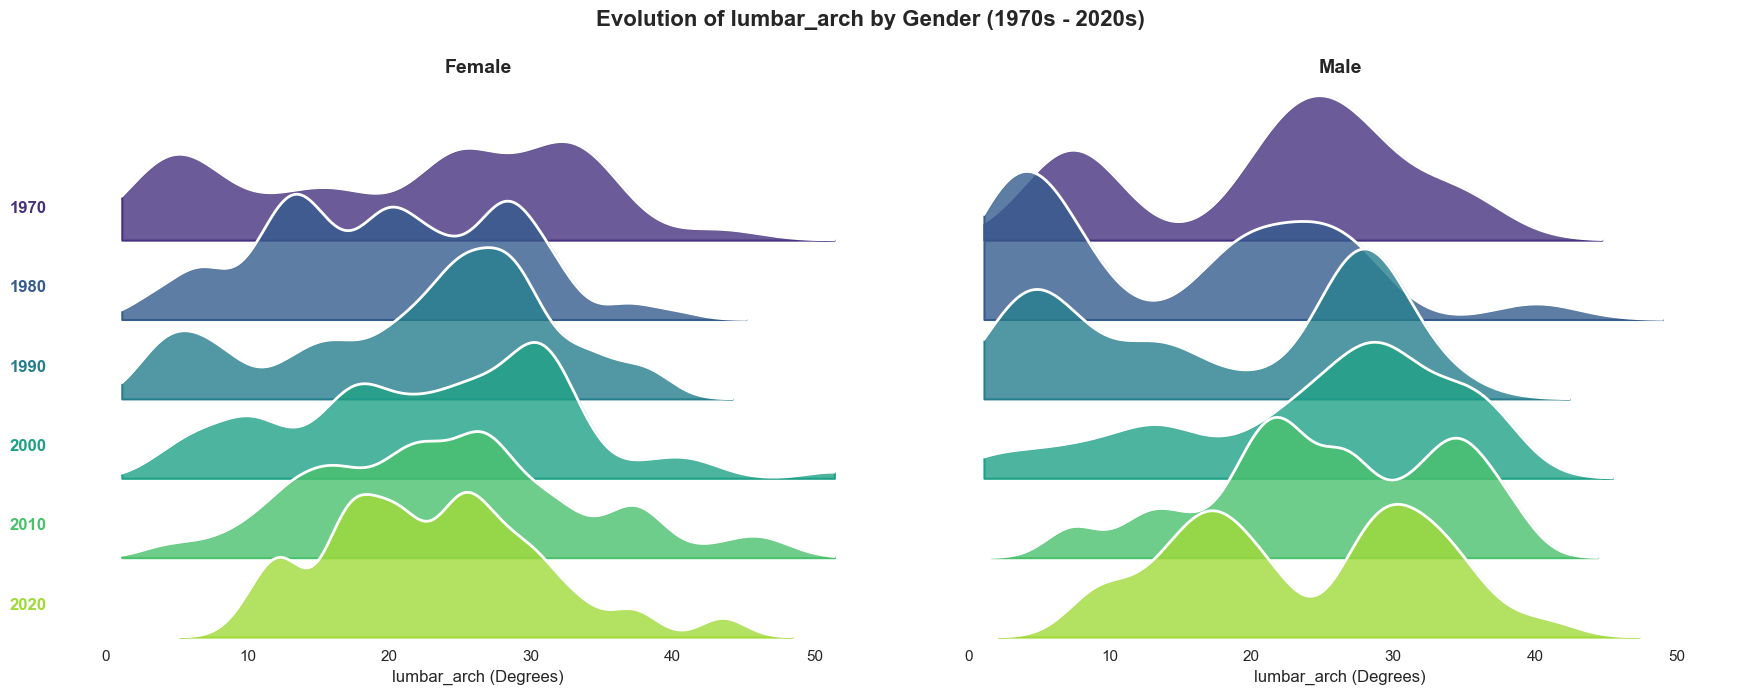

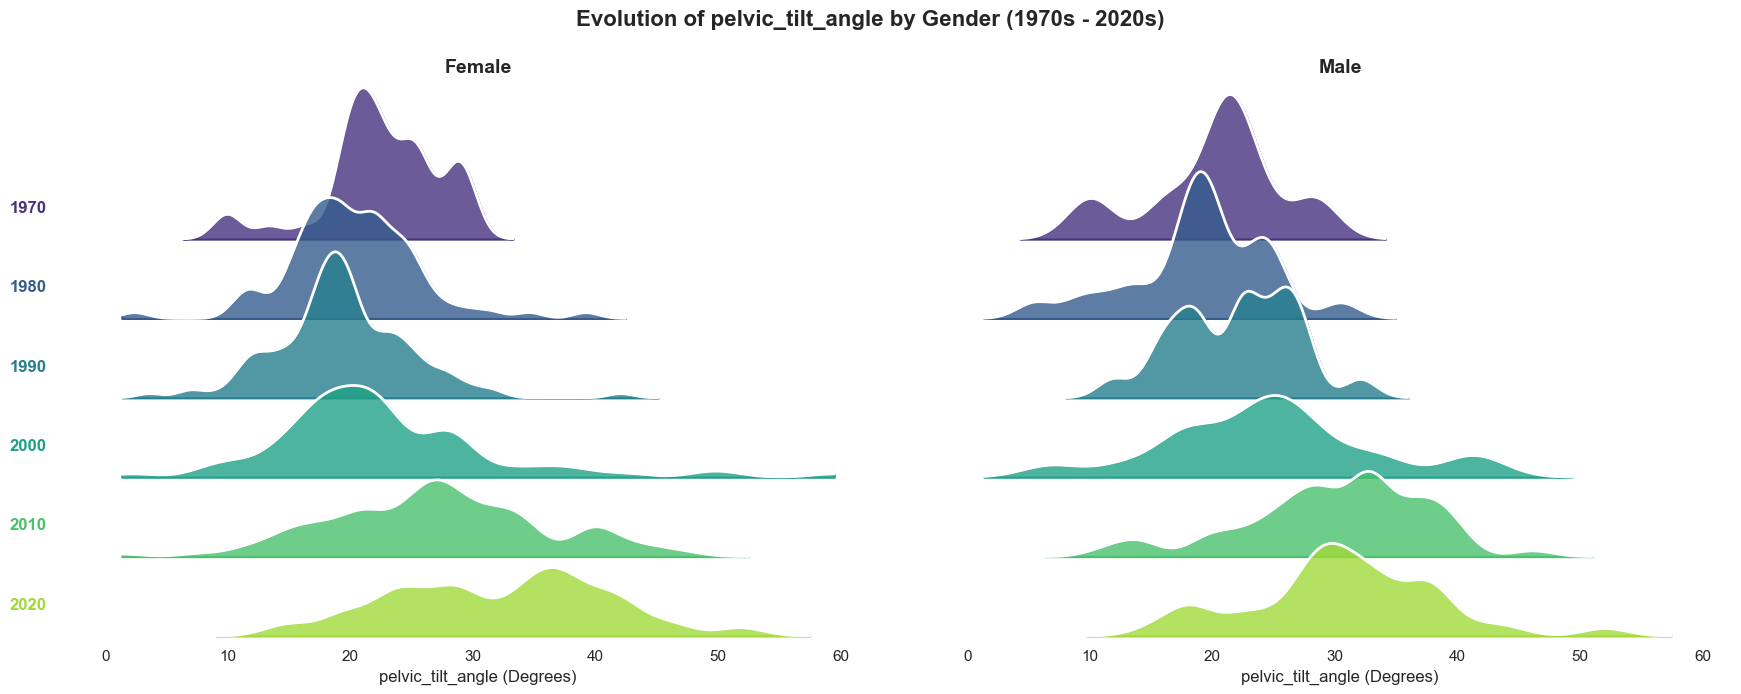

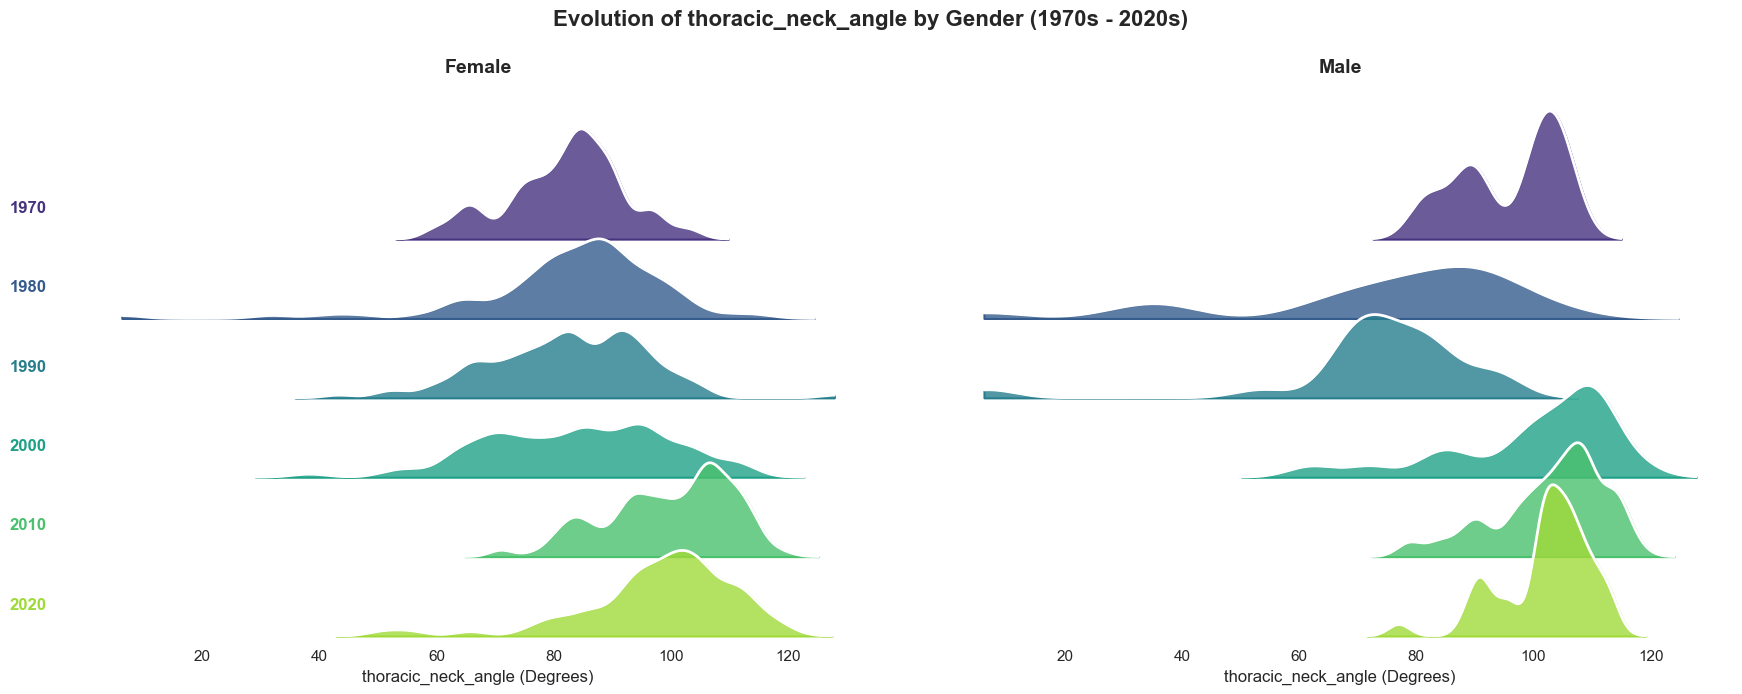

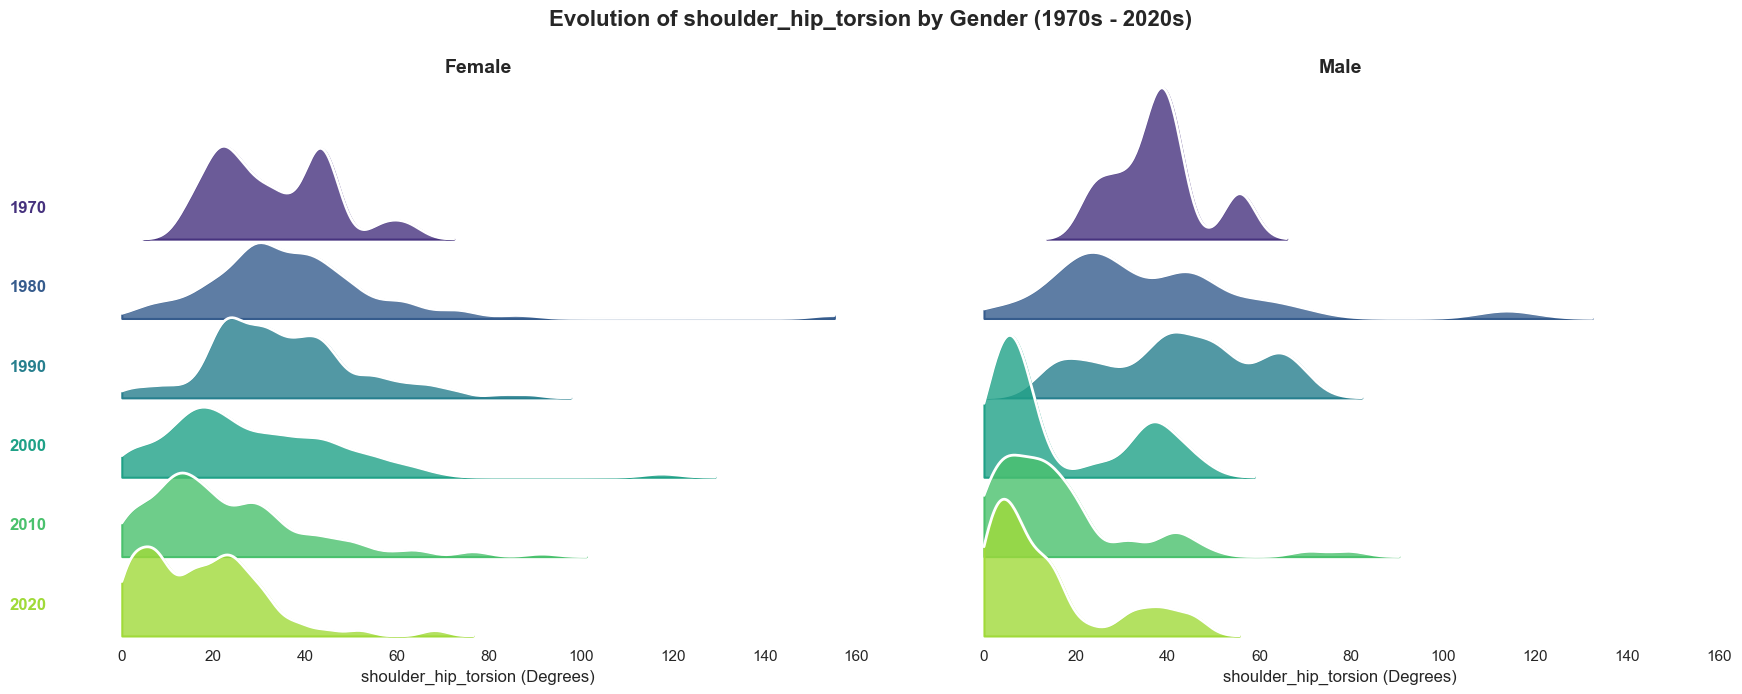

In [15]:
df['decade'] = pd.Categorical(df['decade'], categories=sorted(df['decade'].unique()), ordered=True)

def plot_combined_ridge(data, metric, title):
    df_clean = data.dropna(subset=[metric]).copy()
    
    if df_clean.empty:
        print(f"⚠️ No {metric} data, skip.")
        return
        
    df_clean['gender_label'] = df_clean['real_gender'].map({'F': 'Female', 'M': 'Male'})
    df_clean['gender_label'] = pd.Categorical(df_clean['gender_label'], categories=['Female', 'Male'], ordered=True)
    
    sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
    
    g = sns.FacetGrid(df_clean, row="decade", col="gender_label", hue="decade", 
                      aspect=8, height=1.1, palette="viridis")
    
    min_val = df_clean[metric].min()
    max_val = df_clean[metric].max()
    
    g.map(sns.kdeplot, metric, bw_adjust=.5, clip=(min_val, max_val), clip_on=False, fill=True, alpha=0.8, linewidth=1.5)
    g.map(sns.kdeplot, metric, clip=(min_val, max_val), clip_on=False, color="w", lw=2, bw_adjust=.5)
    
    def label_decade(x, color, label, **kwargs):
        ax = plt.gca()
        if ax.get_subplotspec().colspan.start == 0:
            ax.text(-0.05, 0.2, label, fontweight="bold", color=color,
                    ha="right", va="center", transform=ax.transAxes, fontsize=12)
            
    g.map(label_decade, metric)
    
    g.fig.subplots_adjust(hspace=-0.5, wspace=0.1)
    
    g.set_titles("")
    g.set(yticks=[], ylabel="")
    g.despine(bottom=True, left=True)
    g.axes[0, 0].set_title("Female", fontweight='bold', fontsize=14)
    g.axes[0, 1].set_title("Male", fontweight='bold', fontsize=14)
    
    if metric == 'split_angle':
        for ax in g.axes.flat:
            ax.axvline(180, color='red', linestyle='--', alpha=0.5, zorder=0)
            
    g.set_axis_labels(f"{metric} (Degrees)", "")
    g.fig.suptitle(title, y=1.05, fontsize=16, fontweight='bold')
    
    plt.show()

def plot_ridge_by_gender(data, gender, metric, title):
    df_g = data[data['real_gender'] == gender].dropna(subset=[metric])

    if df_g.empty:
        print(f"⚠️ No {metric} data for {gender}, skip.")
        return
    
    sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
    
    g = sns.FacetGrid(df_g, row="decade", hue="decade", 
                      aspect=8, height=1.1, palette="viridis")
    
    g.map(sns.kdeplot, metric, bw_adjust=.5, clip_on=False, fill=True, alpha=0.8, linewidth=1.5)
    
    g.map(sns.kdeplot, metric, clip_on=False, color="w", lw=2, bw_adjust=.5)
    
    def label(x, color, label):
        ax = plt.gca()
        ax.text(0, .2, label, fontweight="bold", color=color,
                ha="left", va="center", transform=ax.transAxes, fontsize=12)
    g.map(label, metric)
    
    g.fig.subplots_adjust(hspace=-0.5)
    
    g.set_titles("")
    g.set(yticks=[], ylabel="")
    g.despine(bottom=True, left=True)
    
    if metric == 'split_angle':
        for ax in g.axes.flat:
            ax.axvline(180, color='red', linestyle='--', alpha=0.5, zorder=0)
        
    g.fig.suptitle(title, y=1.01, fontsize=16, fontweight='bold')
    plt.xlabel(f"{metric} (Degrees)")
    plt.show()

for metric in target_metrics:
    title_combined = f"Evolution of {metric} by Gender (1970s - 2020s)"
    plot_combined_ridge(df, metric, title_combined)

In [15]:
start_decade = df['decade'].min()
end_decade = df['decade'].max()

print("="*60)
print("📊 Distribution Evolution Test")
print("="*60)

for metric in target_metrics:
    print(f"\n" + "="*60)
    print(f"Feature: {metric}")
    print("="*60)
    for gender in ['F', 'M']:
        print(f"\n----- {gender} -----")
        
        df_g = df[(df['real_gender'] == gender)].dropna(subset=[metric, 'decade'])
        
        if df_g.empty: continue

        # ==========================================
        # Kolmogorov-Smirnov Test
        # ==========================================
        data_start = df_g[df_g['decade'] == start_decade][metric]
        data_end = df_g[df_g['decade'] == end_decade][metric]
        
        ks_stat, p_ks = stats.ks_2samp(data_start, data_end)
        sig_ks = "***" if p_ks < 0.001 else ("**" if p_ks < 0.01 else ("*" if p_ks < 0.05 else "ns"))
        
        print(f"  K-S Test (Overall distribution shift): D={ks_stat:.3f}, p={p_ks:.4f} {sig_ks}")
        if p_ks < 0.05:
            print(f"    >>> {start_decade}s vs. {end_decade}s: Significantly Different Distributions.")

📊 Distribution Evolution Test

Feature: split_angle

----- F -----
  K-S Test (Overall distribution shift): D=0.454, p=0.0000 ***
    >>> 1970s vs. 2020s: Significantly Different Distributions.

----- M -----
  K-S Test (Overall distribution shift): D=0.561, p=0.0300 *
    >>> 1970s vs. 2020s: Significantly Different Distributions.

Feature: support_leg_plumb

----- F -----
  K-S Test (Overall distribution shift): D=0.637, p=0.0000 ***
    >>> 1970s vs. 2020s: Significantly Different Distributions.

----- M -----
  K-S Test (Overall distribution shift): D=0.561, p=0.0300 *
    >>> 1970s vs. 2020s: Significantly Different Distributions.

Feature: torso_tilt

----- F -----
  K-S Test (Overall distribution shift): D=0.413, p=0.0002 ***
    >>> 1970s vs. 2020s: Significantly Different Distributions.

----- M -----
  K-S Test (Overall distribution shift): D=0.449, p=0.1218 ns

Feature: arabesque_angle

----- F -----
  K-S Test (Overall distribution shift): D=0.487, p=0.0000 ***
    >>> 1970

In [16]:
target_metric = 'split_angle'

baseline_year = int(df['year'].min())
df['year_centered'] = df['year'] - baseline_year
df['real_gender'] = pd.Categorical(df['real_gender'], categories=['F', 'M'], ordered=True)

print("="*70)
print(f"📊 Testing Gender Asymmetry in Extreme Evolution (Multiple Quantile Regression q=0.90)")
print("="*70)

def get_sig(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

for metric in target_metrics:
    print(f"\n▶ Feature: 【{metric}】")
    
    df_clean = df.dropna(subset=[metric, 'year_centered', 'real_gender'])
    if df_clean.empty:
        print("  ⚠️ No data, skip.")
        continue

    formula = f'{metric} ~ year_centered * C(real_gender)'

    try:
        mod = smf.quantreg(formula, df_clean)
        res = mod.fit(q=0.90, max_iter=2000) 
        
        coef_year_F = res.params['year_centered']
        coef_interaction = res.params['year_centered:C(real_gender)[T.M]']
        slope_M = coef_year_F + coef_interaction
        
        p_year_F = res.pvalues['year_centered']
        p_interaction = res.pvalues['year_centered:C(real_gender)[T.M]']
        
        print(f"  [Female Extreme (90th Pct)]: {coef_year_F:+.3f}° / year | p={p_year_F:.4f} {get_sig(p_year_F)}")
        print(f"  [Male Extreme (90th Pct)]:   {slope_M:+.3f}° / year")
        
        if p_interaction < 0.05:
            faster = "Female" if abs(coef_year_F) > abs(slope_M) else "Male"
            print(f"  [Gender Gap / Interaction]:  Significant (p={p_interaction:.4f} {get_sig(p_interaction)})")
            print(f"                               -> [Asymmetric Evolution]: {faster} dancers are evolving significantly faster at the extreme limit.")
        else:
            print(f"  [Gender Gap / Interaction]:  Not Significant (p={p_interaction:.4f} {get_sig(p_interaction)})")
            print(f"                               -> [Parallel Evolution]: Male and female extremes are advancing at the same rate (statistically parallel slopes).")

    except Exception as e:
        print(f"  ❌ Model fitting failed: {e}")

📊 Testing Gender Asymmetry in Extreme Evolution (Multiple Quantile Regression q=0.90)

▶ Feature: 【split_angle】
  [Female Extreme (90th Pct)]: +0.205° / year | p=0.0003 ***
  [Male Extreme (90th Pct)]:   +0.404° / year
  [Gender Gap / Interaction]:  Not Significant (p=0.1158 ns)
                               -> [Parallel Evolution]: Male and female extremes are advancing at the same rate (statistically parallel slopes).

▶ Feature: 【support_leg_plumb】
  [Female Extreme (90th Pct)]: +0.570° / year | p=0.0000 ***
  [Male Extreme (90th Pct)]:   +0.468° / year
  [Gender Gap / Interaction]:  Not Significant (p=0.2646 ns)
                               -> [Parallel Evolution]: Male and female extremes are advancing at the same rate (statistically parallel slopes).

▶ Feature: 【torso_tilt】
  [Female Extreme (90th Pct)]: +0.295° / year | p=0.0000 ***
  [Male Extreme (90th Pct)]:   +0.145° / year
  [Gender Gap / Interaction]:  Not Significant (p=0.0692 ns)
                               -> [Pa

#### 3D Skeleton Visualization

In [17]:
connections = [
    ("Pelvis", "Spine"), ("Spine", "Thorax"), ("Thorax", "Neck"), ("Neck", "Head"),
    ("Thorax", "L_Shoulder"), ("L_Shoulder", "L_Elbow"), ("L_Elbow", "L_Wrist"),
    ("Thorax", "R_Shoulder"), ("R_Shoulder", "R_Elbow"), ("R_Elbow", "R_Wrist"),
    ("Pelvis", "L_Hip"), ("L_Hip", "L_Knee"), ("L_Knee", "L_Ankle"),
    ("Pelvis", "R_Hip"), ("R_Hip", "R_Knee"), ("R_Knee", "R_Ankle")
]

joints_order = [
    "Pelvis", "R_Hip", "R_Knee", "R_Ankle", "L_Hip", "L_Knee", "L_Ankle",
    "Spine", "Thorax", "Neck", "Head", "L_Shoulder", "L_Elbow", "L_Wrist",
    "R_Shoulder", "R_Elbow", "R_Wrist"
]

# ==========================================
# Procrustes Alignment
# ==========================================
def get_aligned_mean_skeleton(df_subset, base_skeleton_matrix):
    all_skeletons = []
    
    for _, row in df_subset.iterrows():
        json_path = row['json_path'] 
        try:
            with open(json_path, 'r') as f:
                data = json.load(f)
            
            skel_dict = data['skeleton_3d']
            matrix = np.array([skel_dict[j] for j in joints_order])
            
            _, mtx2, _ = procrustes(base_skeleton_matrix, matrix)
            all_skeletons.append(mtx2)
            
        except Exception as e:
            continue
            
    mean_matrix = np.mean(all_skeletons, axis=0)
    
    return {joints_order[i]: mean_matrix[i] for i in range(len(joints_order))}

base_json_path = df.iloc[0]['json_path']
with open(base_json_path, 'r') as f:
    base_data = json.load(f)
base_skeleton = np.array([base_data['skeleton_3d'][j] for j in joints_order])

df_1970_f = df[(df['decade'] == '1970') & (df['real_gender'] == 'F')]
df_2020_f = df[(df['decade'] == '2020') & (df['real_gender'] == 'F')]

mean_skel_1970_f = get_aligned_mean_skeleton(df_1970_f, base_skeleton)
mean_skel_2020_f = get_aligned_mean_skeleton(df_2020_f, base_skeleton)

df_1970_m = df[(df['decade'] == '1970') & (df['real_gender'] == 'M')]
df_2020_m = df[(df['decade'] == '2020') & (df['real_gender'] == 'M')]

mean_skel_1970_m = get_aligned_mean_skeleton(df_1970_m, base_skeleton)
mean_skel_2020_m = get_aligned_mean_skeleton(df_2020_m, base_skeleton)

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'scene'}, {'type': 'scene'}]],
    subplot_titles=("Female (1970s vs 2020s)", "Male (1970s vs 2020s)")
)

def add_skeleton_to_fig(fig, skel_dict, color, name, row, col, show_legend_flag):
    x = [skel_dict[j][0] for j in joints_order]
    y = [skel_dict[j][1] for j in joints_order]
    z = [skel_dict[j][2] for j in joints_order]
    
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z, mode='markers',
        marker=dict(size=4, color=color),
        name=f"{name} Joints", showlegend=False
    ), row=row, col=col)
    
    for j1, j2 in connections:
        p1, p2 = skel_dict[j1], skel_dict[j2]
        is_first_line = (j1 == "Pelvis" and j2 == "Spine")
        
        fig.add_trace(go.Scatter3d(
            x=[p1[0], p2[0]], y=[p1[1], p2[1]], z=[p1[2], p2[2]],
            mode='lines', line=dict(color=color, width=5),
            name=name, showlegend=(is_first_line and show_legend_flag)
        ), row=row, col=col)

color_1970 = 'rgba(231, 76, 60, 0.8)'
color_2020 = 'rgba(52, 152, 219, 0.8)'

add_skeleton_to_fig(fig, mean_skel_1970_f, color_1970, '1970s Mean', row=1, col=1, show_legend_flag=True)
add_skeleton_to_fig(fig, mean_skel_2020_f, color_2020, '2020s Mean', row=1, col=1, show_legend_flag=True)

add_skeleton_to_fig(fig, mean_skel_1970_m, color_1970, '1970s Mean', row=1, col=2, show_legend_flag=False)
add_skeleton_to_fig(fig, mean_skel_2020_m, color_2020, '2020s Mean', row=1, col=2, show_legend_flag=False)

default_camera = dict(eye=dict(x=1.5, y=1.2, z=0.5))

fig.update_layout(
    scene=dict(
        xaxis=dict(title='X (Width)'),
        yaxis=dict(title='Y (Depth)'),
        zaxis=dict(title='Z (Height)'),
        aspectmode='data',
        camera=default_camera
    ),
    scene2=dict(
        xaxis=dict(title='X (Width)'),
        yaxis=dict(title='Y (Depth)'),
        zaxis=dict(title='Z (Height)'),
        aspectmode='data',
        camera=default_camera
    ),
    title="Biomechanical Shift: 1970s vs 2020s Average Arabesque",
    title_x=0.5,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig.show()